## Sea Slugs time series data
This notebook demonstrates how to fit hierarchical Hakwes functions (HHF) with scaled exponential excitation and inhibition functions to the Sea Slugs time series data. First, we import the data:

In [2]:
import numpy as np
## Import csv
X = np.loadtxt('../data/time_series.csv', delimiter=',', skiprows=1, dtype=object)
z = np.loadtxt('../data/partition.txt') - 1
## Remove first two columns
X = X[:, 2:]
## Convert to float
X = X.astype(np.float64)

The *Python* functions used to fit the HHF are all in the package `hierarchical_hawkes`. Instructions for installation can be found in the main `README` file for this repository. 

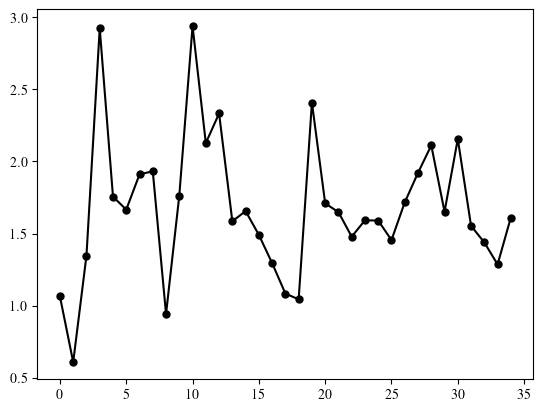

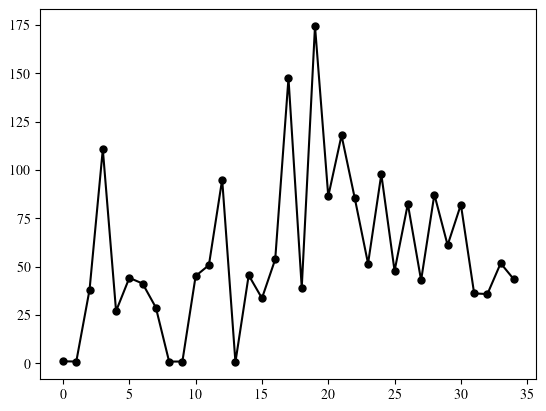

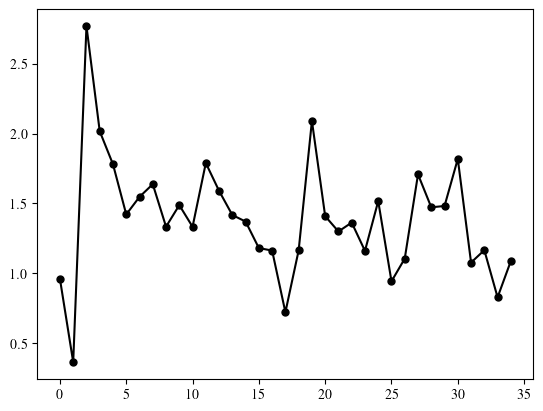

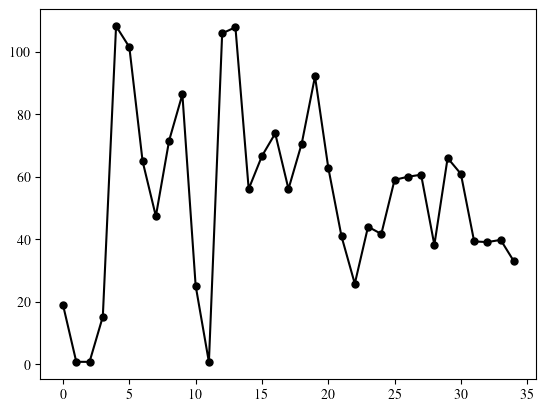

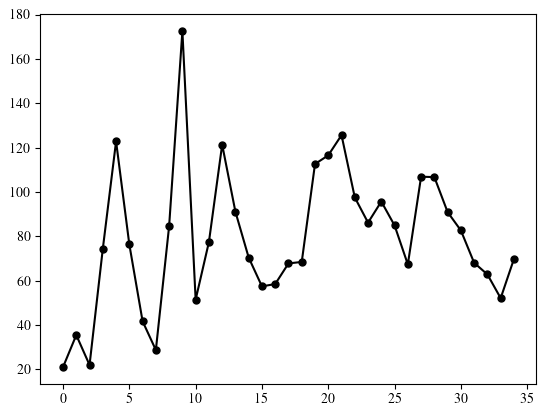

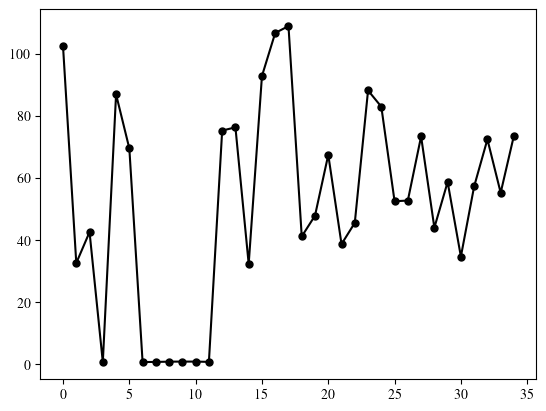

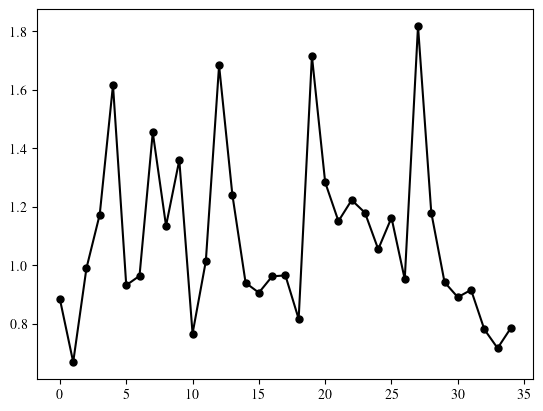

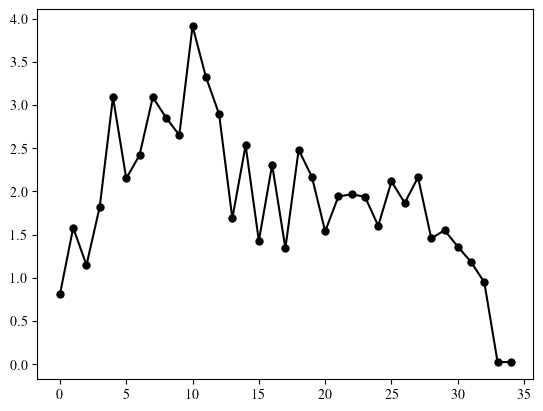

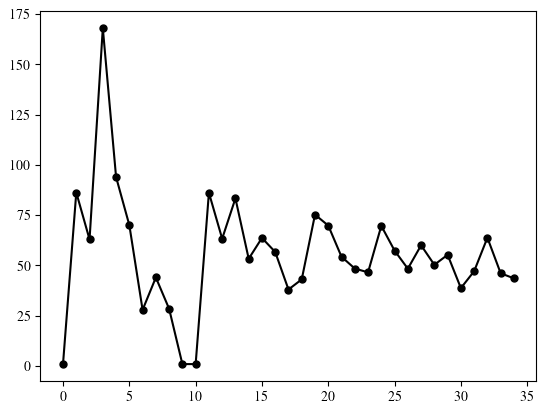

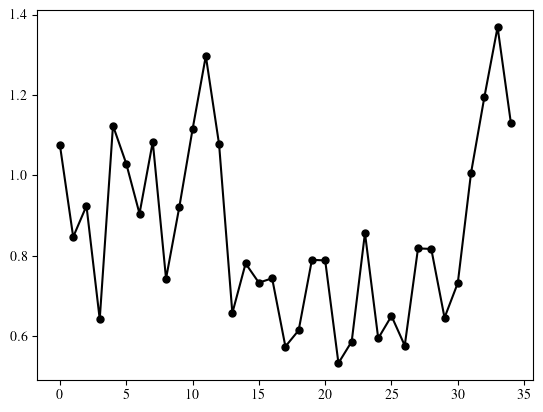

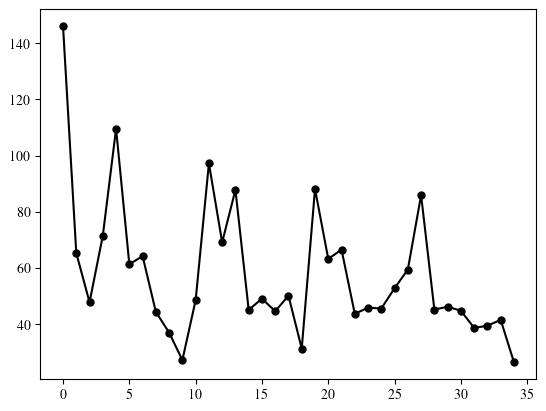

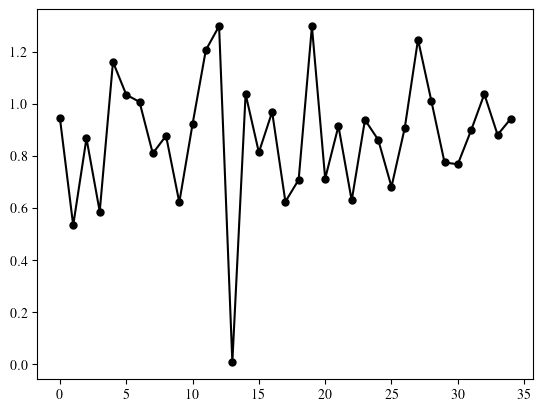

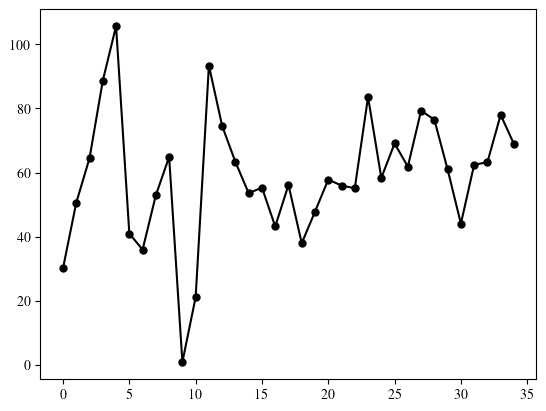

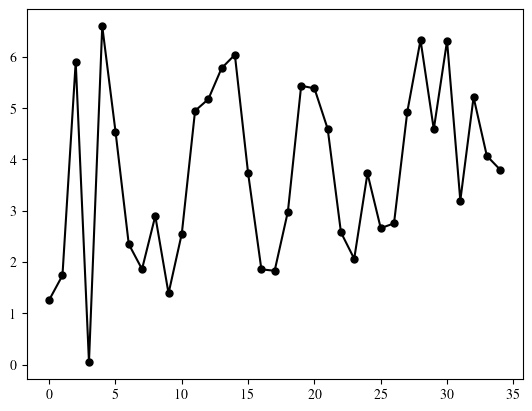

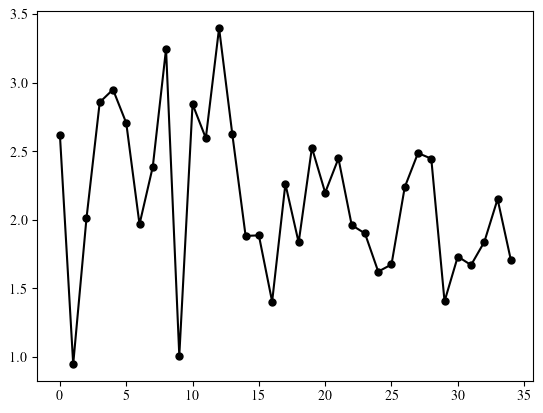

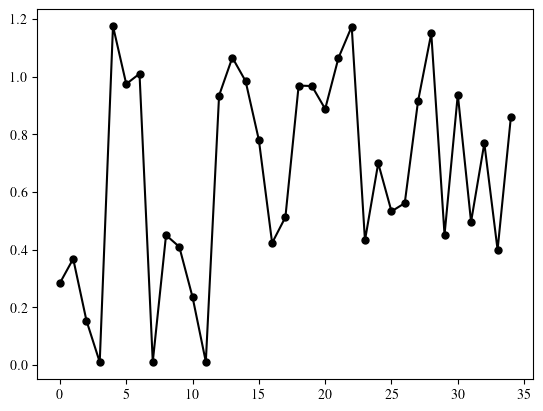

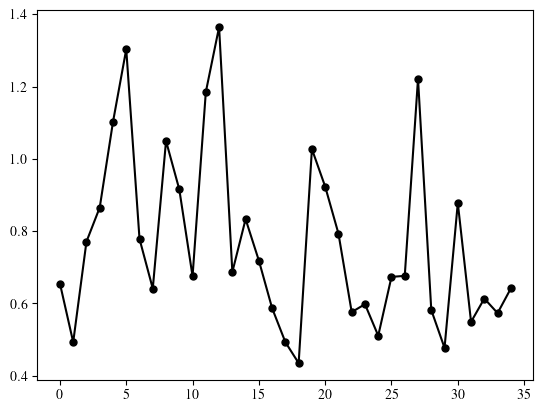

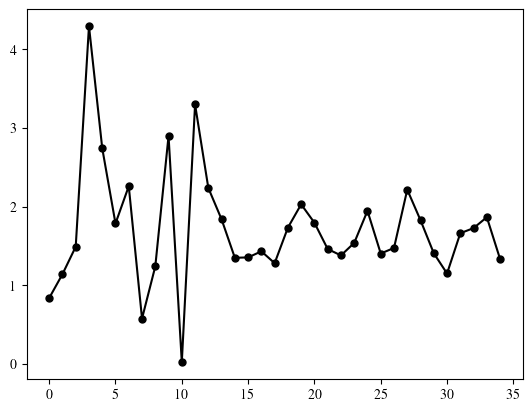

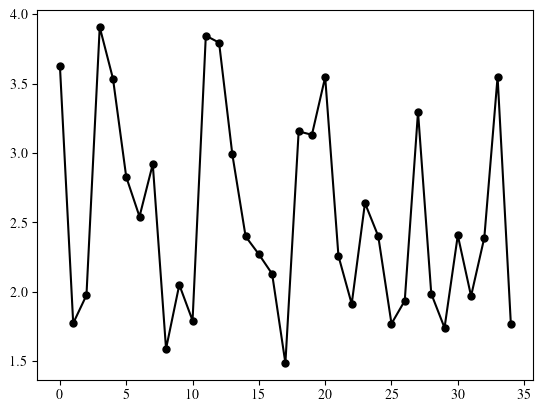

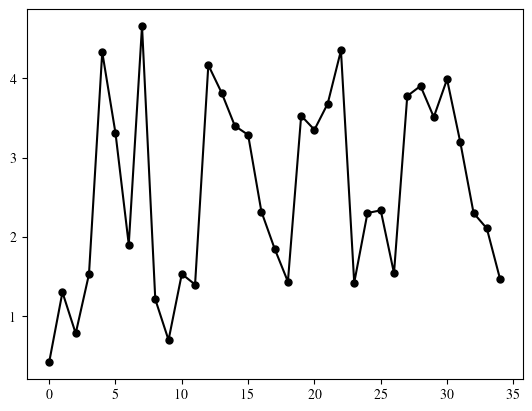

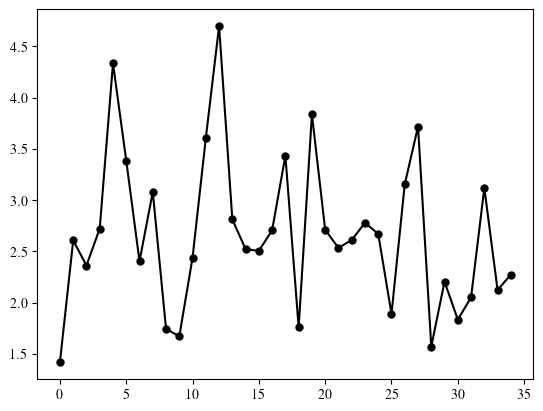

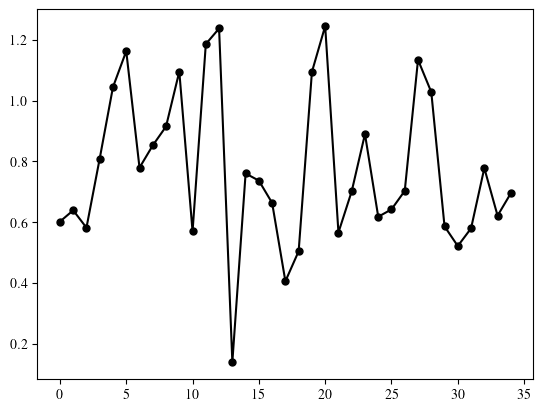

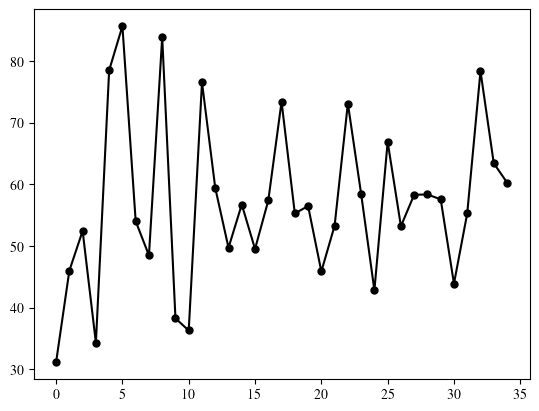

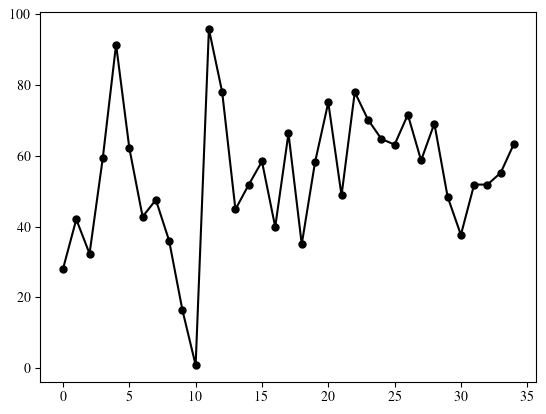

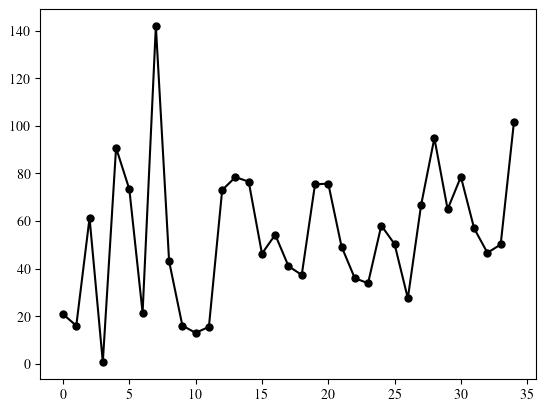

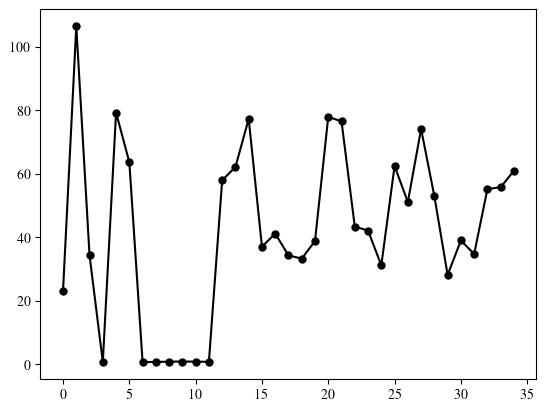

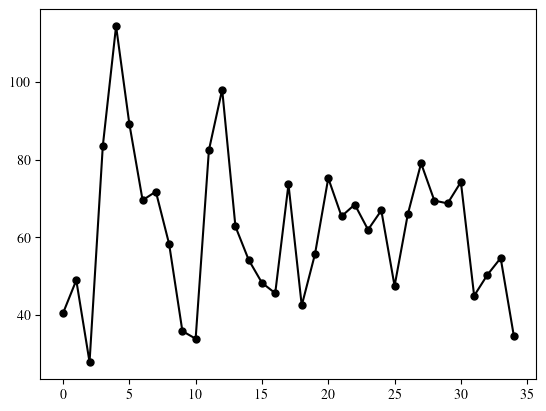

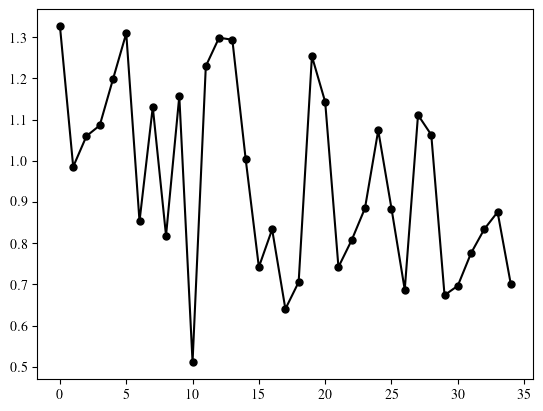

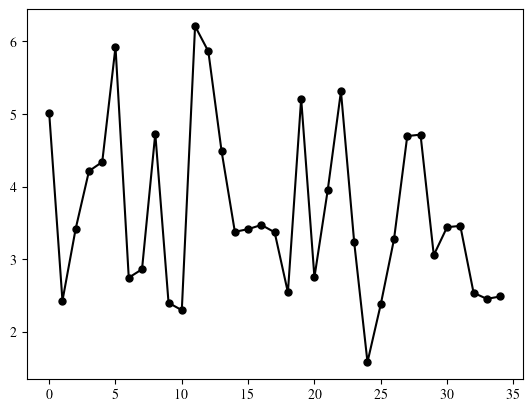

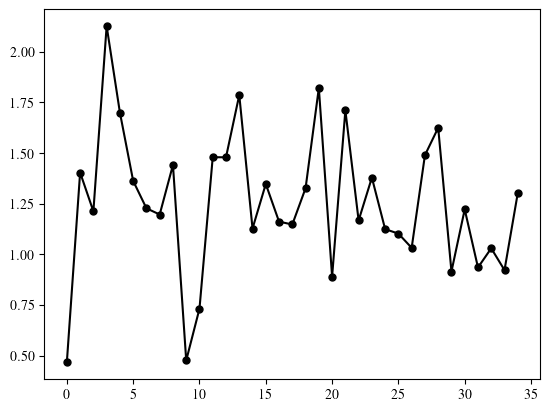

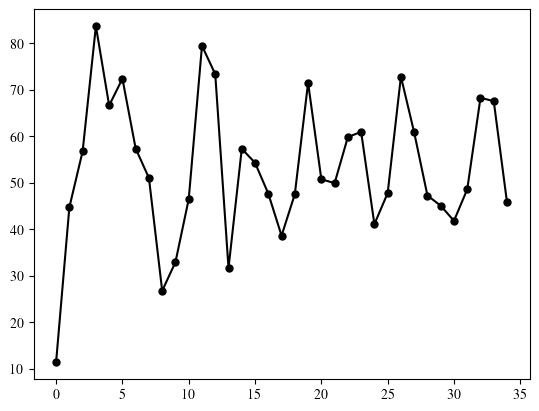

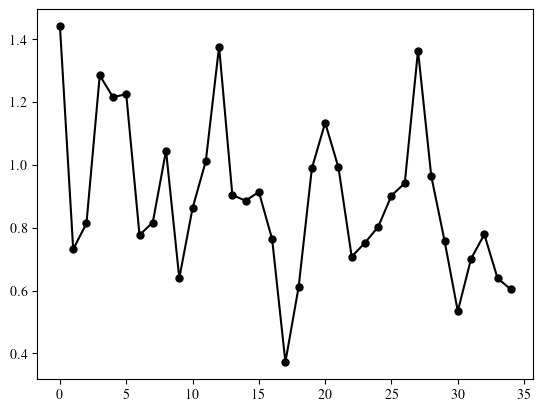

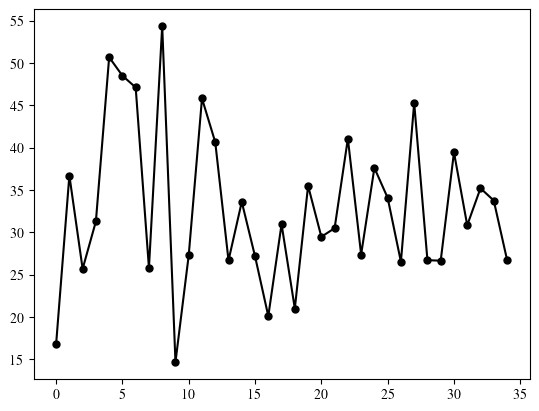

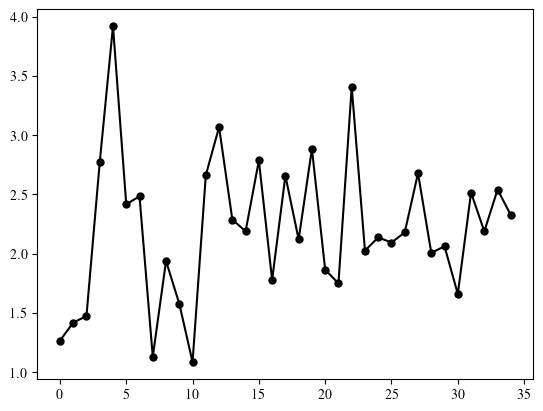

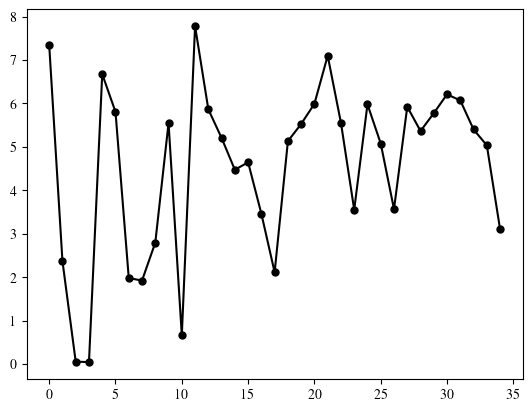

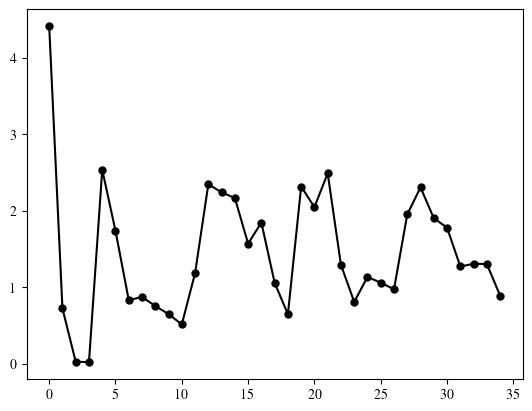

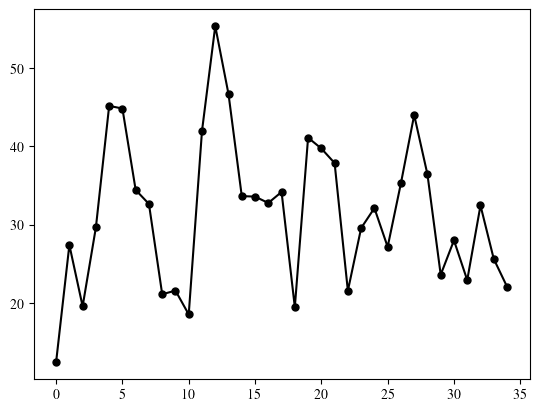

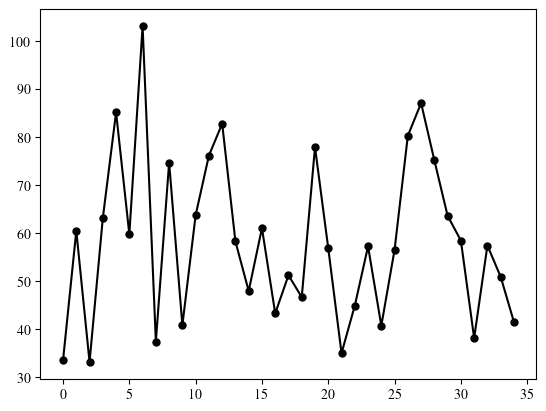

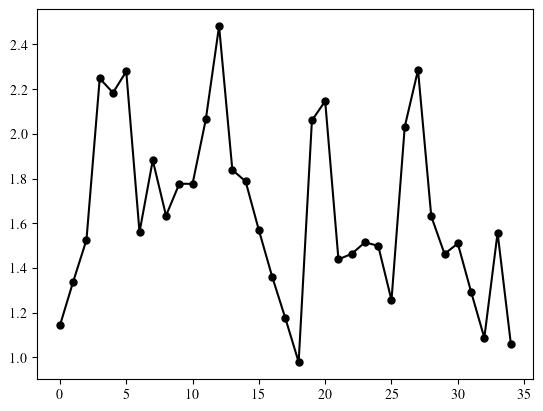

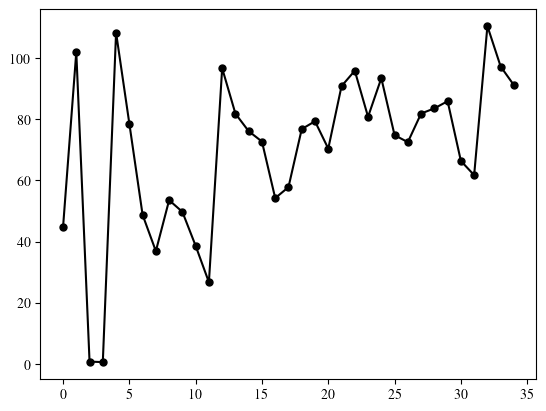

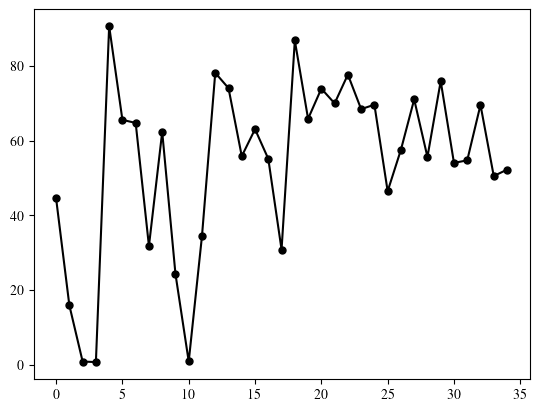

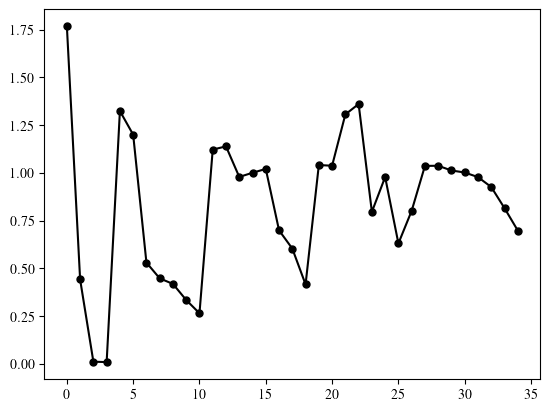

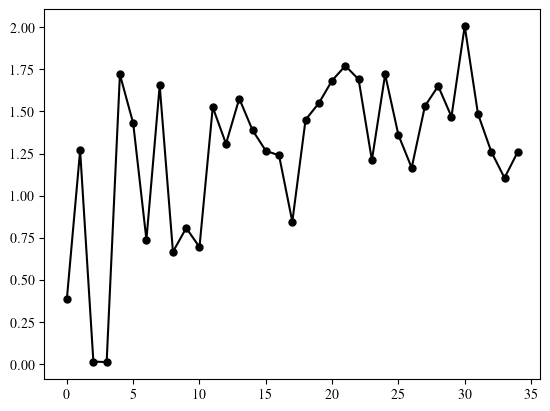

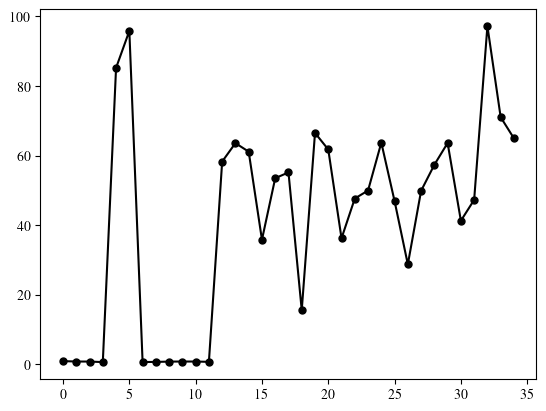

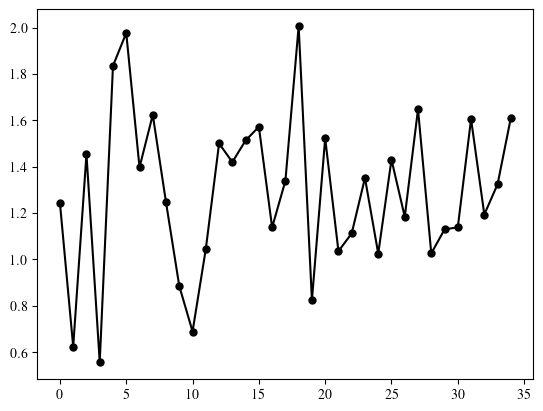

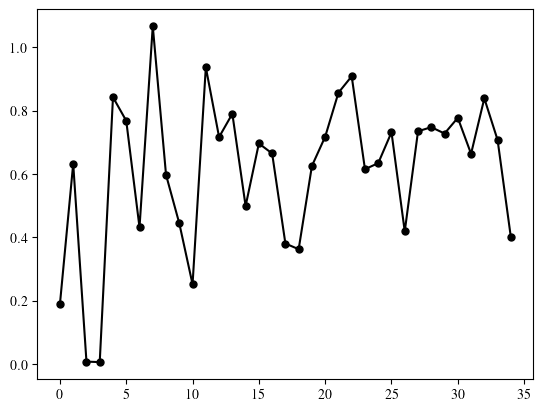

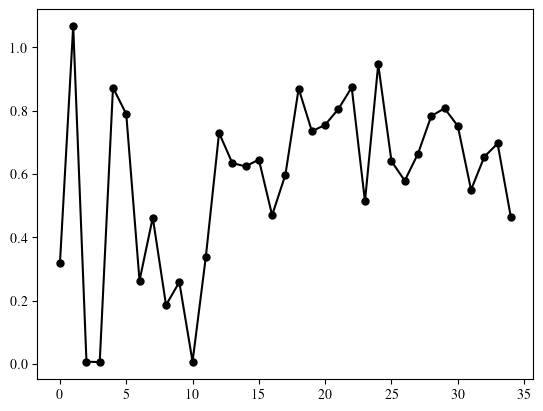

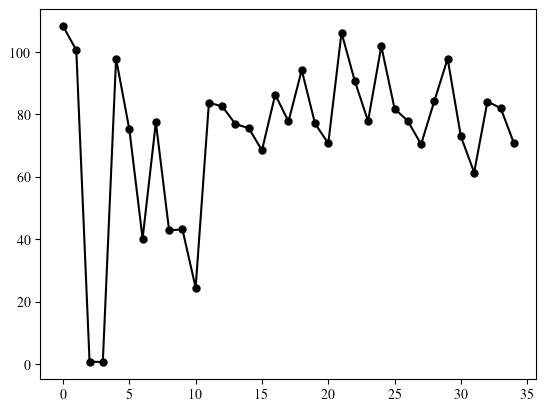

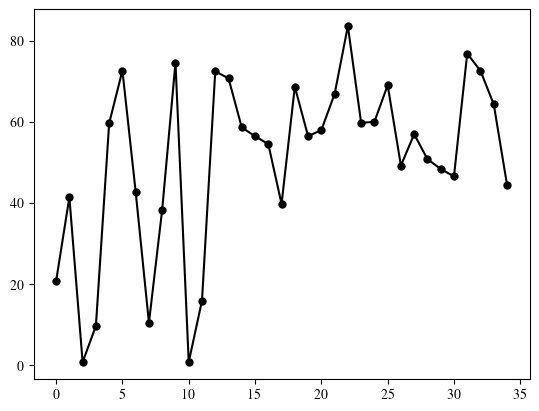

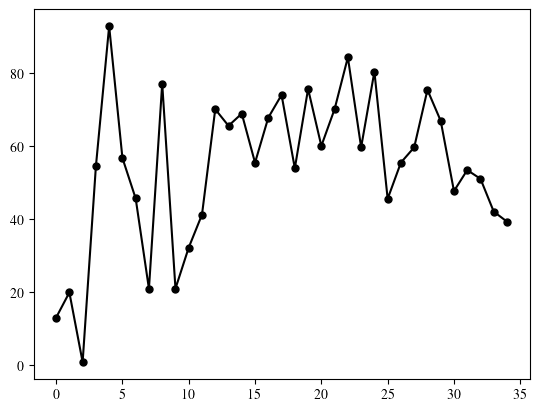

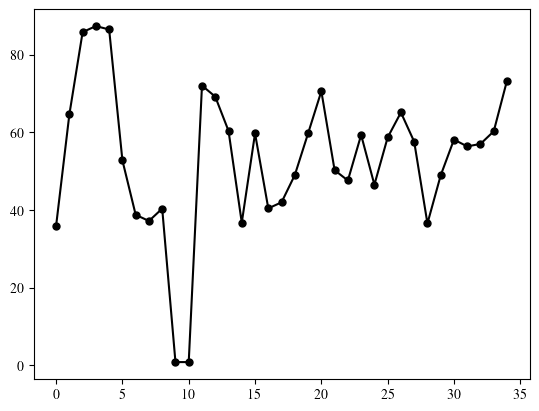

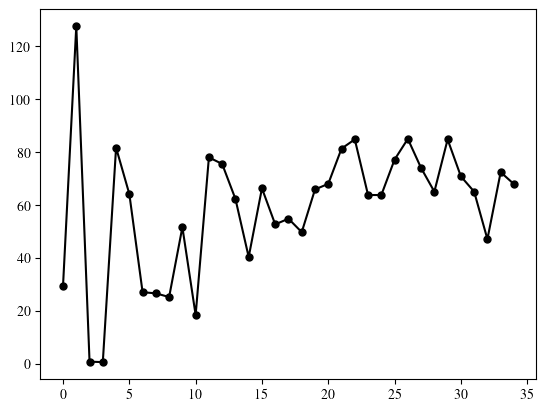

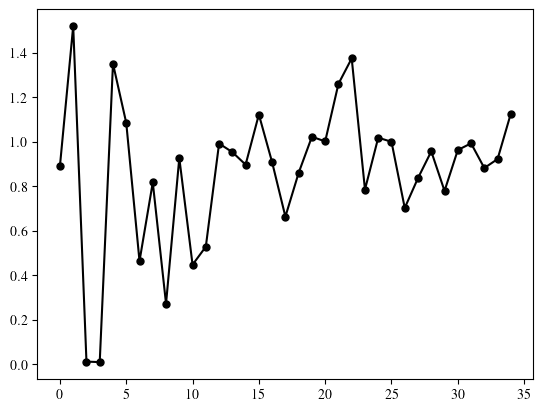

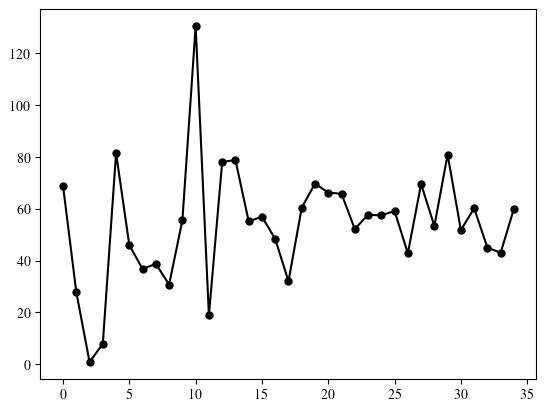

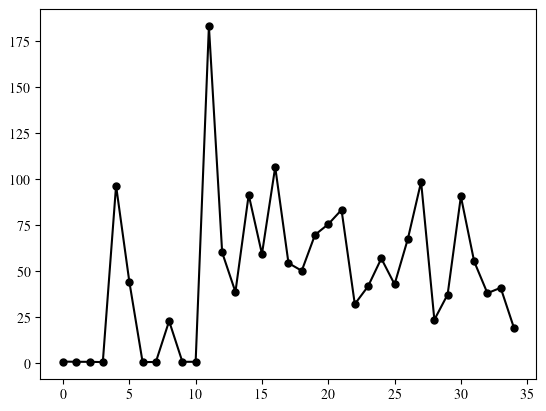

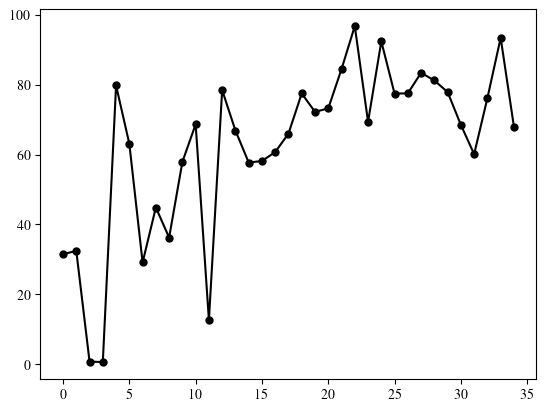

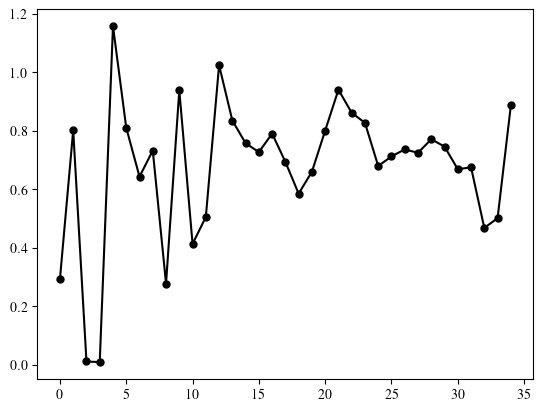

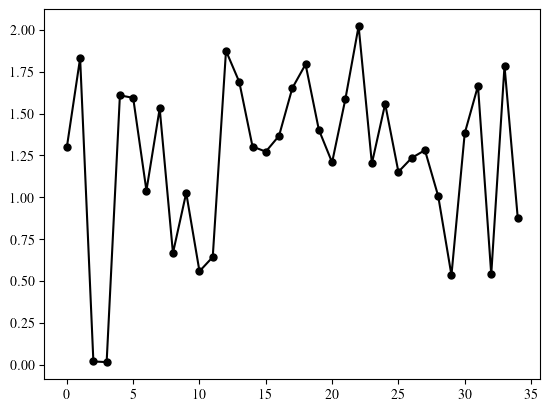

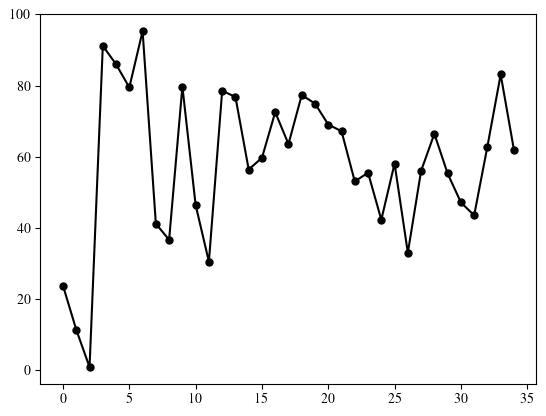

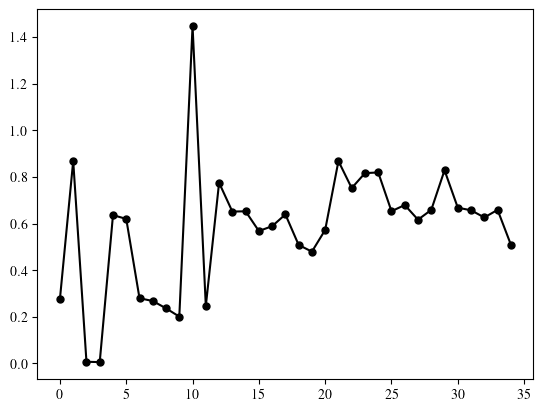

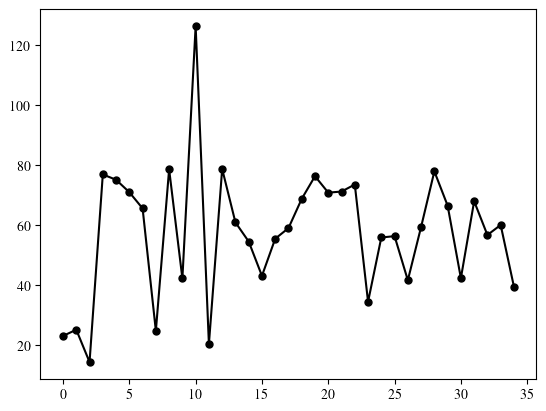

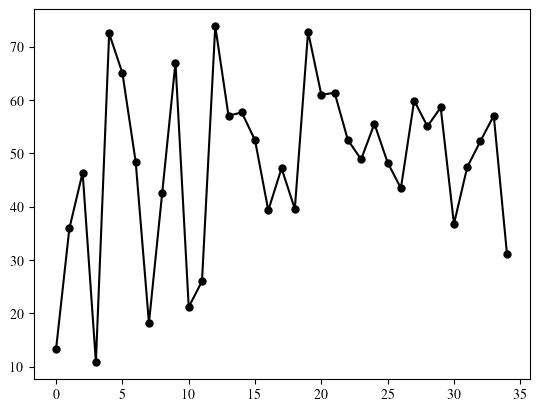

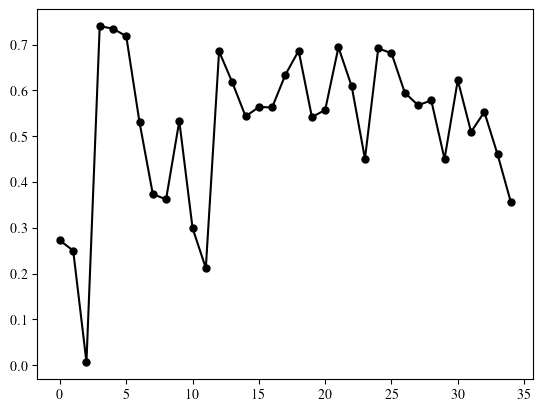

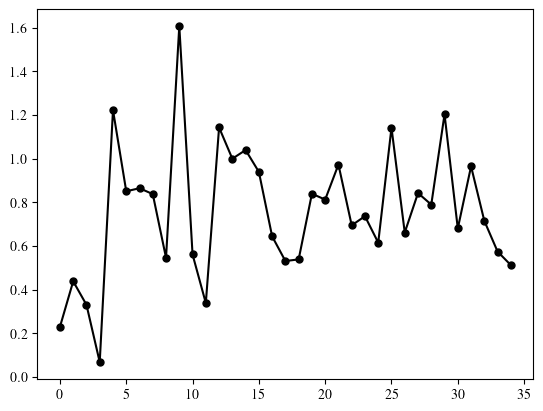

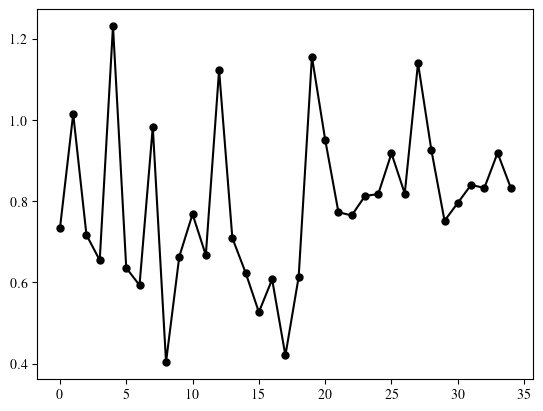

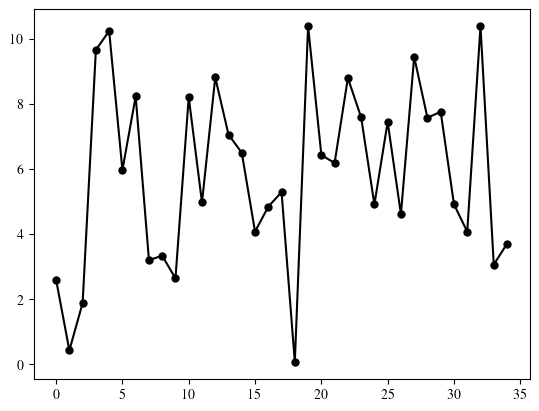

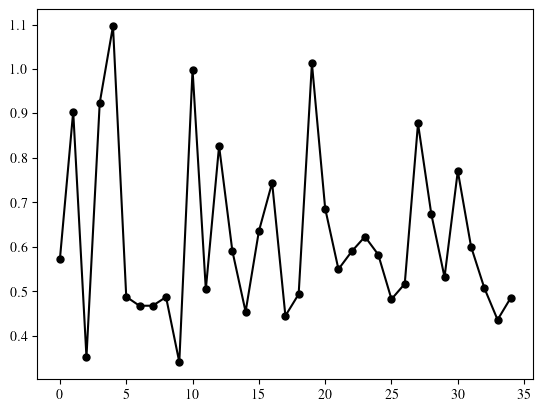

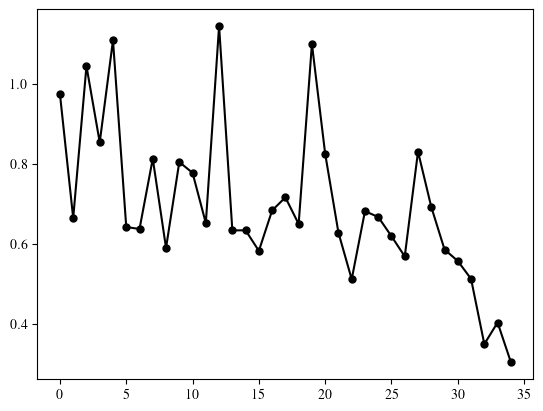

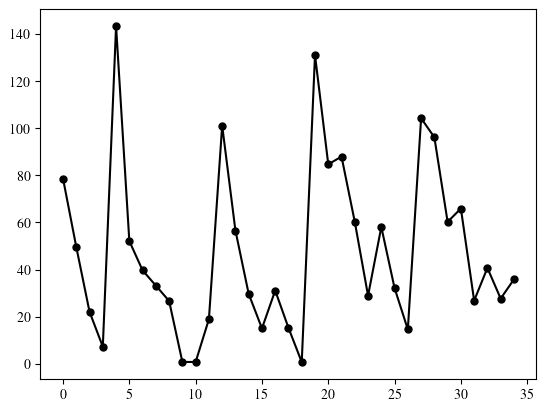

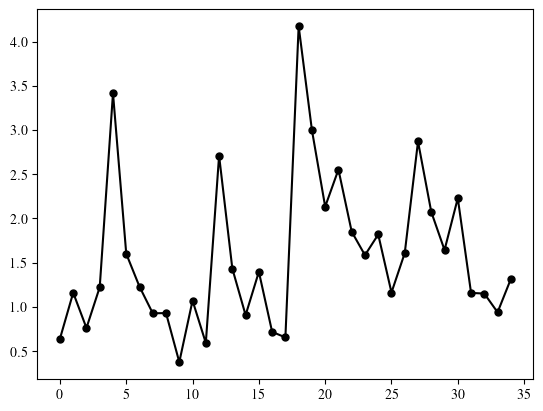

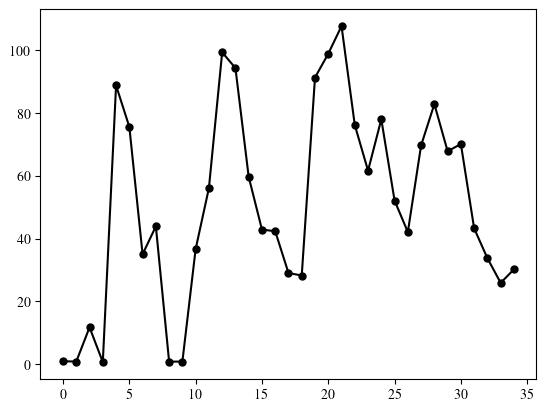

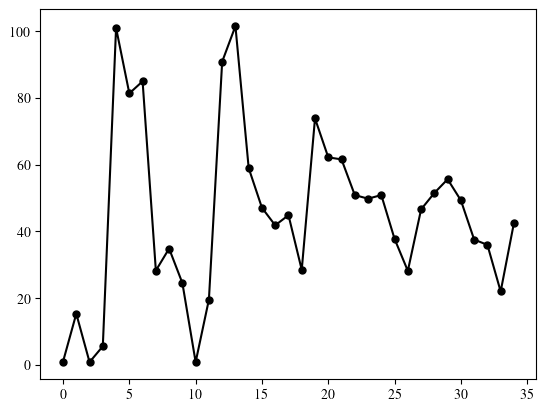

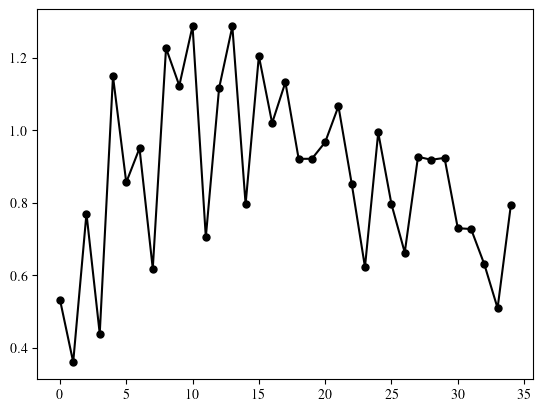

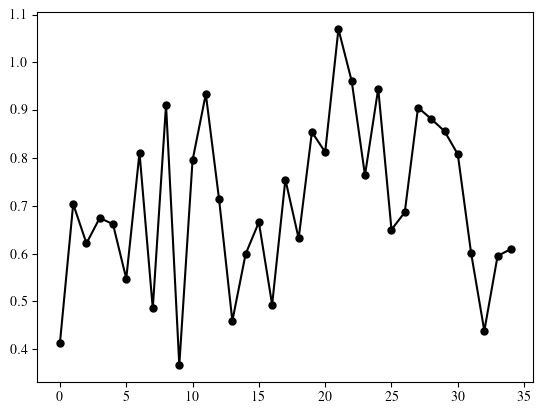

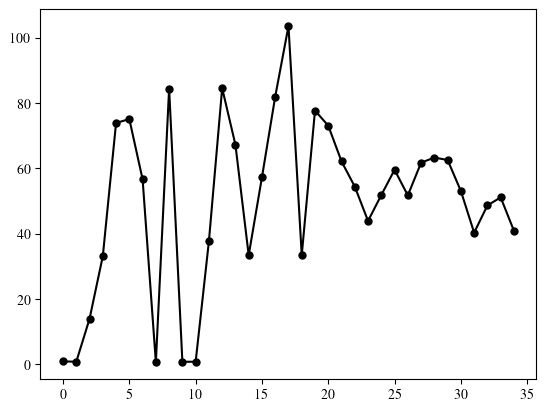

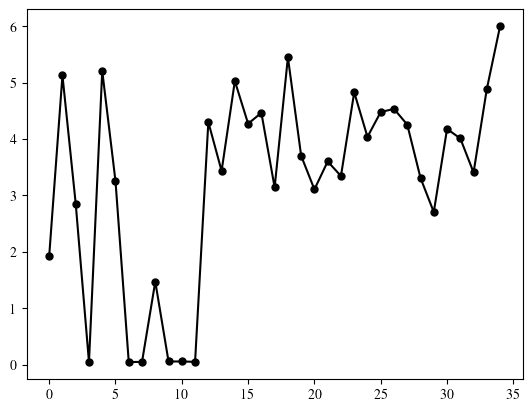

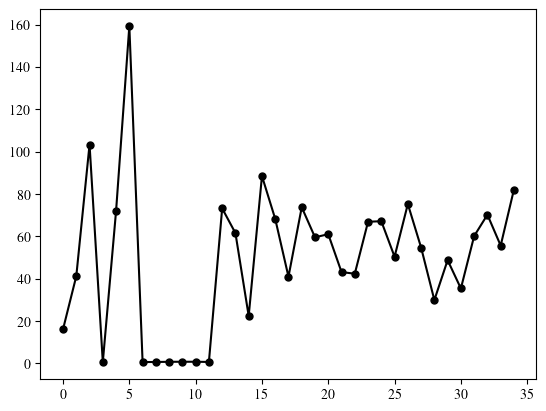

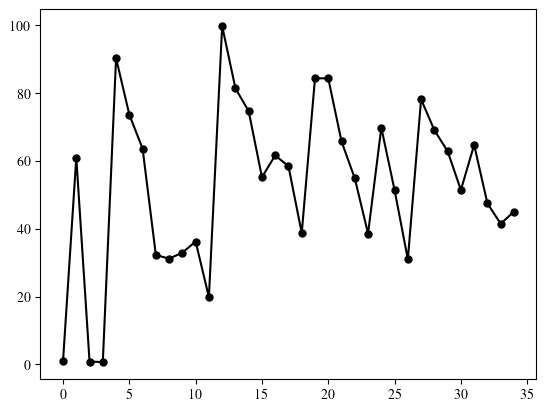

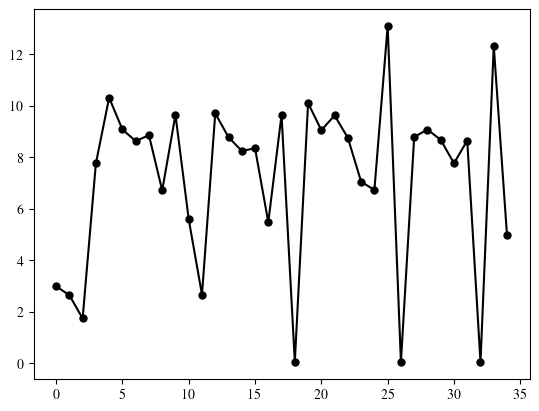

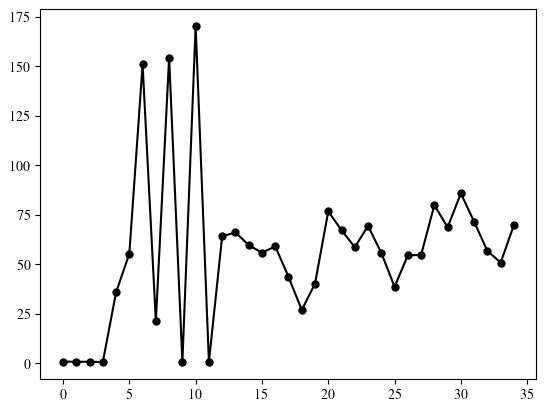

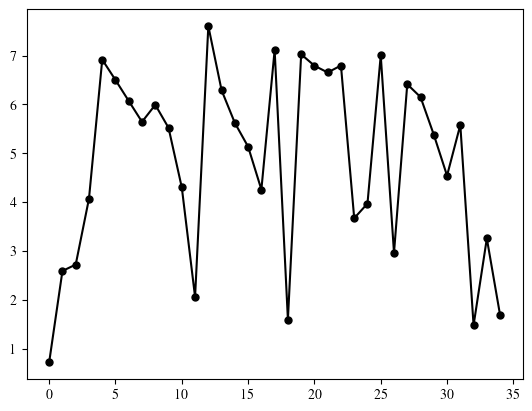

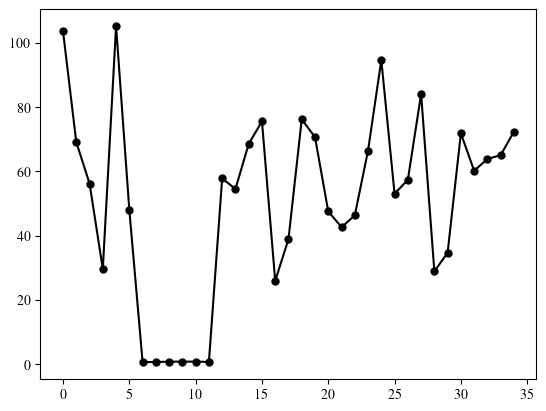

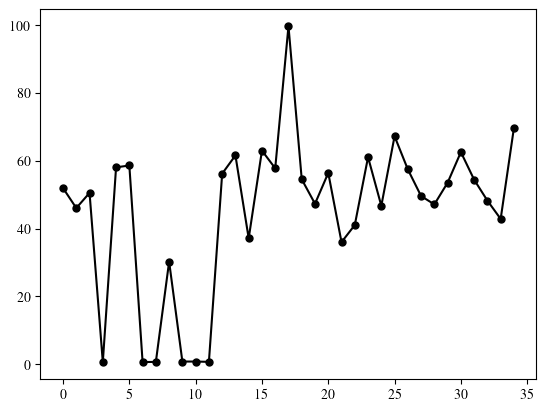

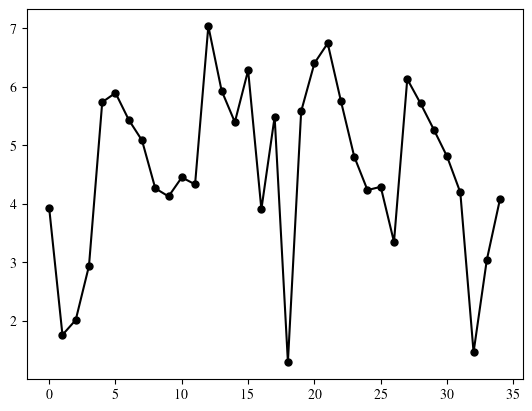

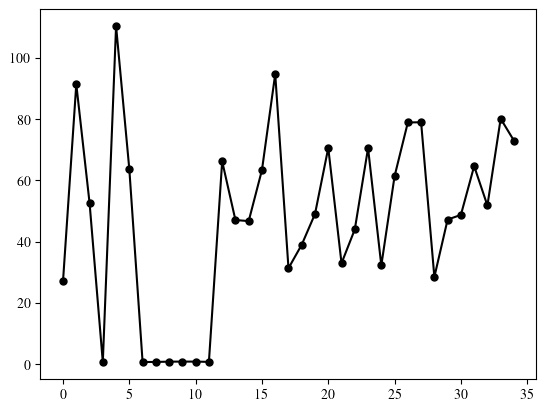

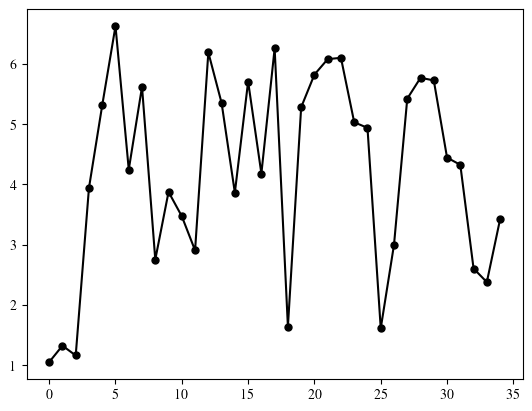

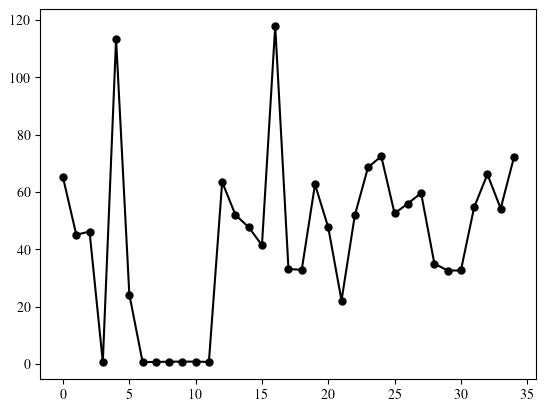

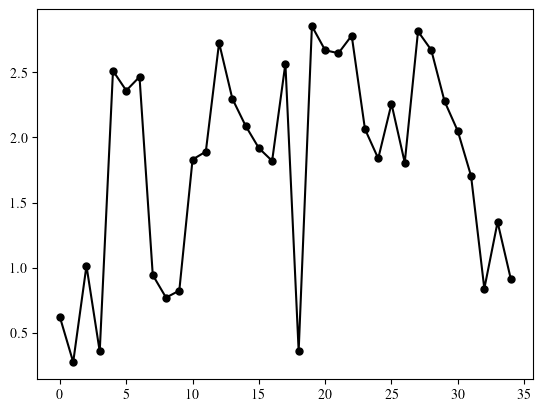

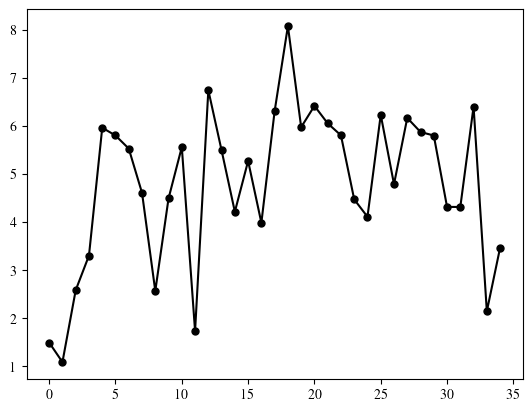

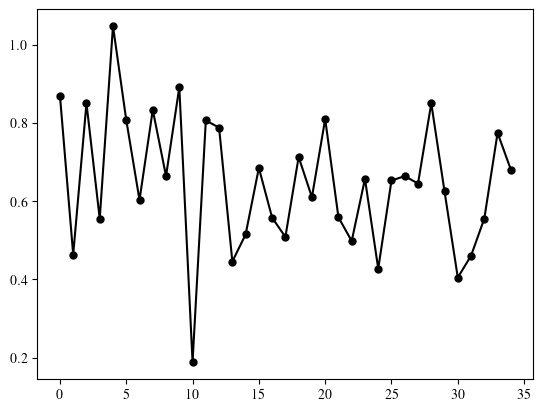

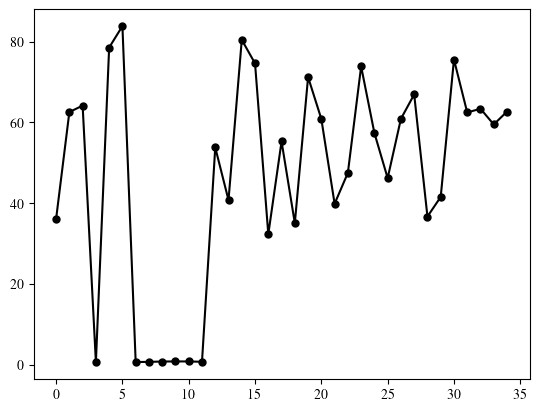

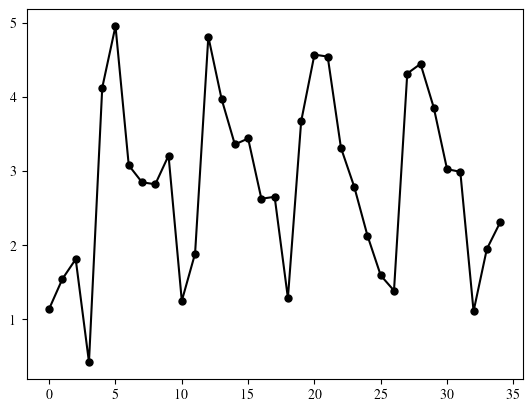

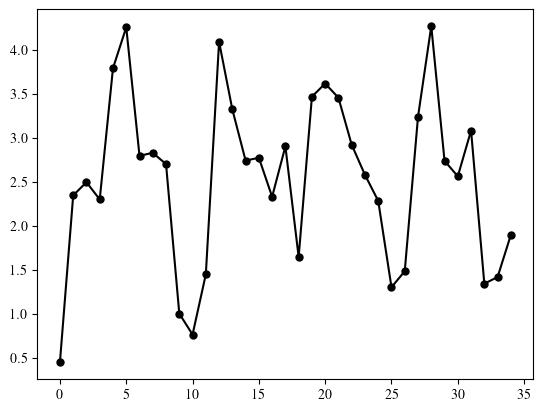

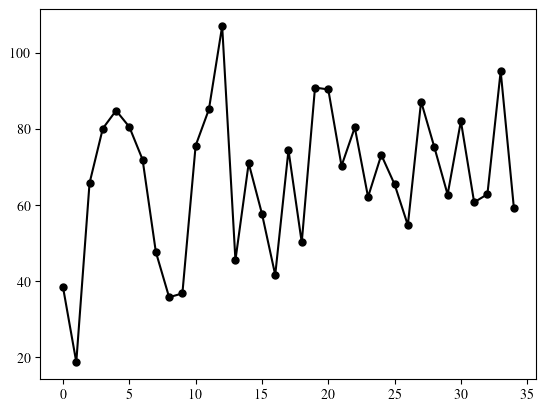

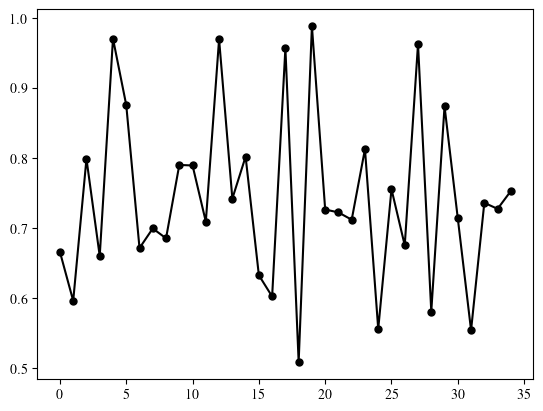

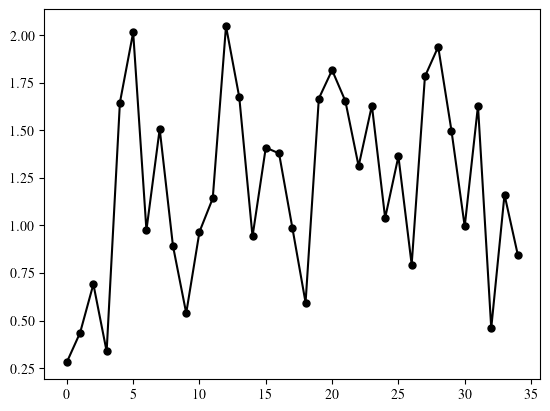

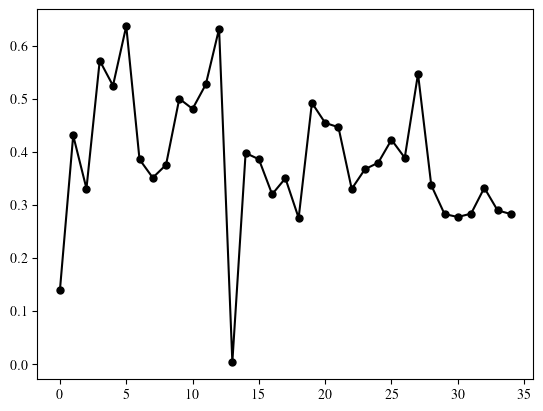

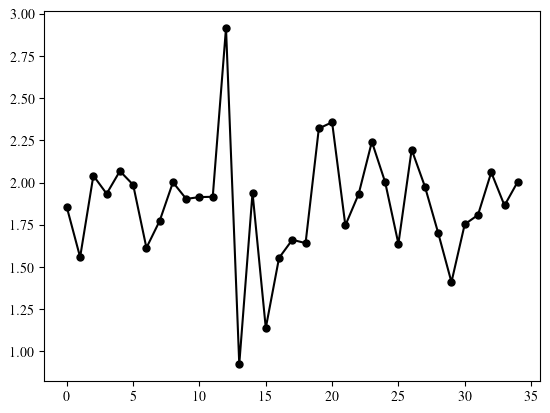

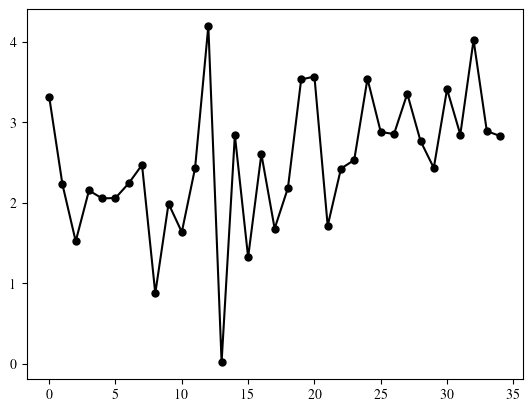

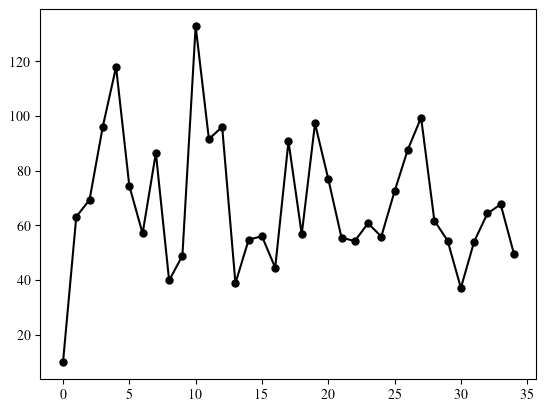

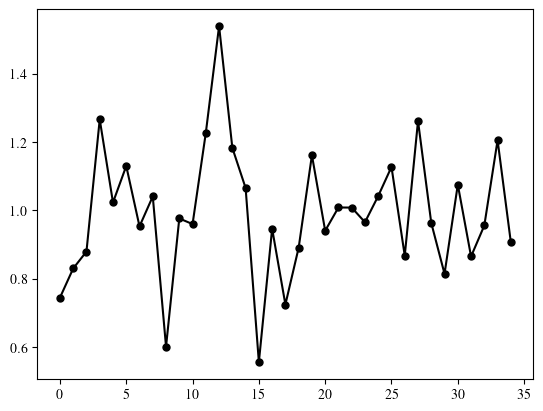

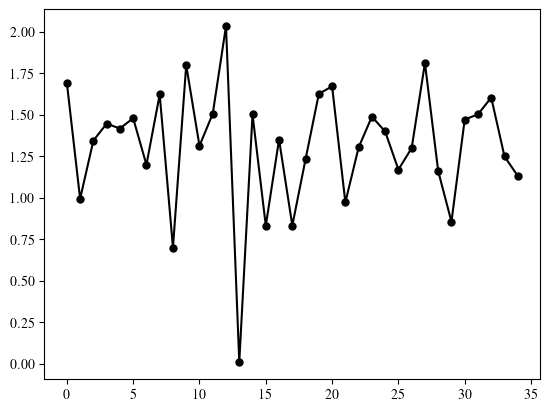

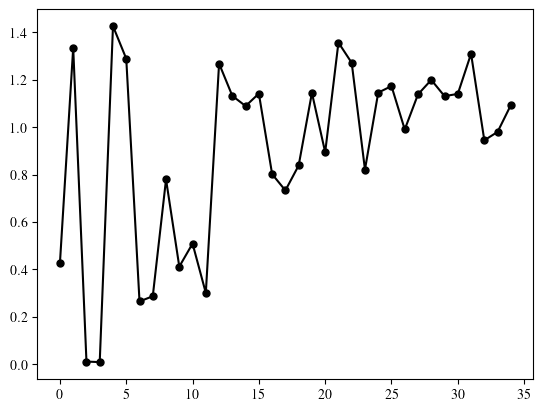

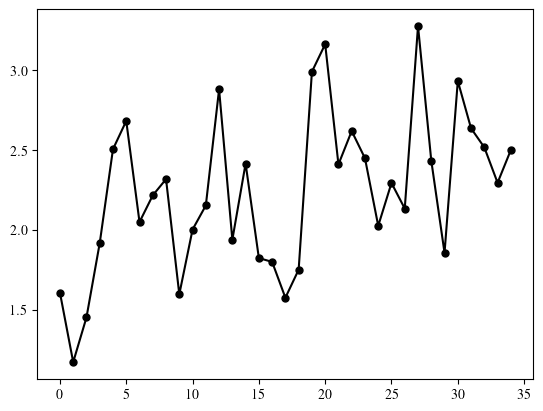

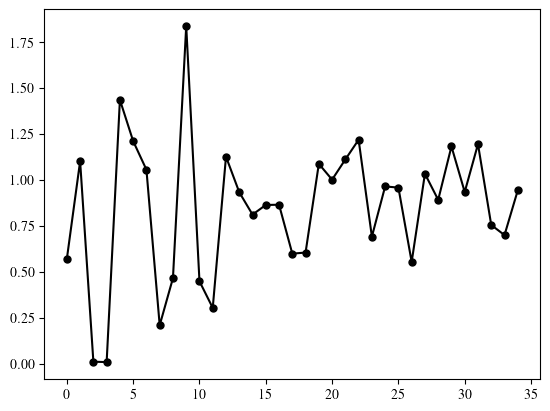

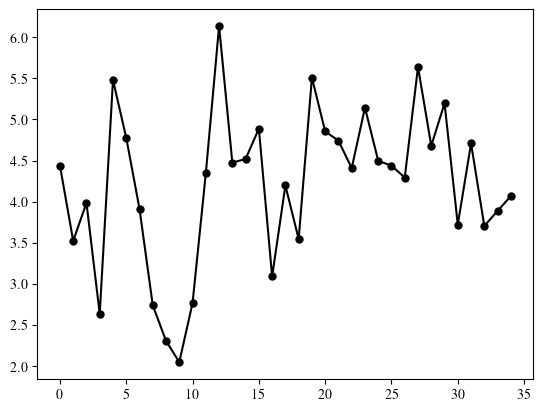

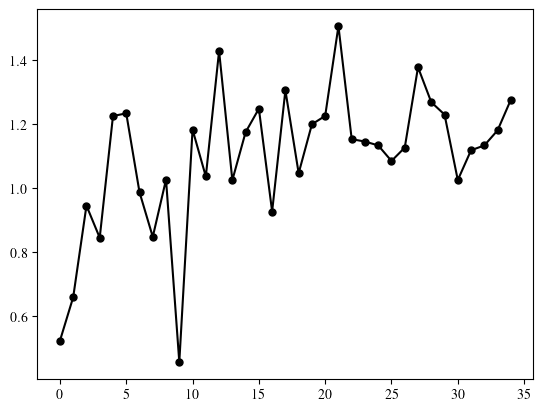

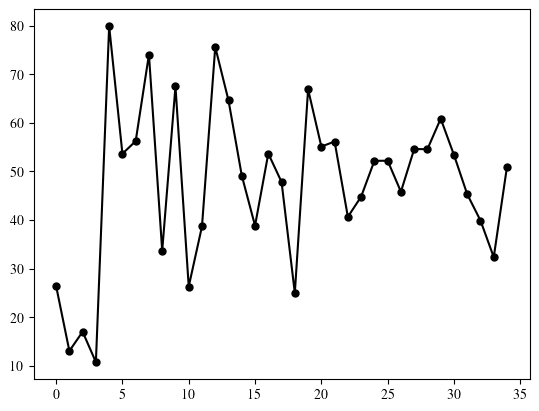

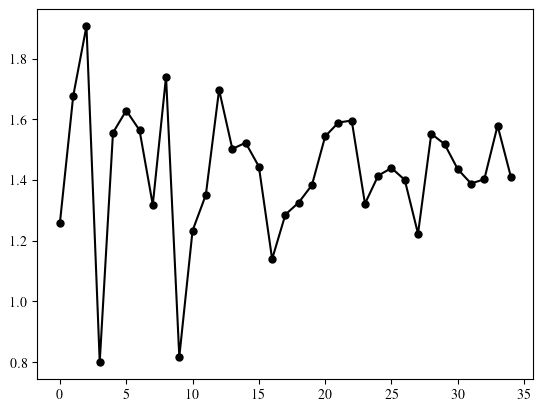

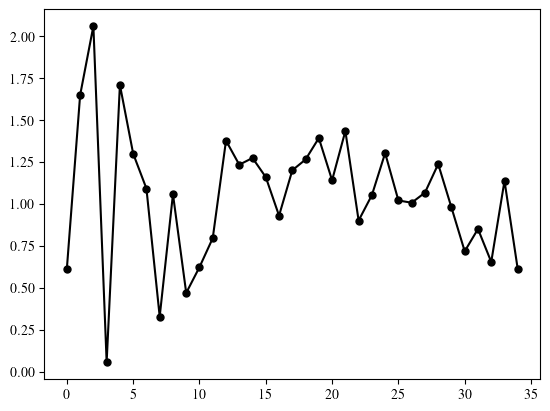

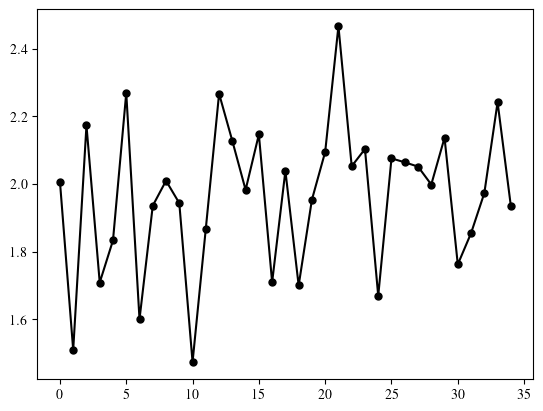

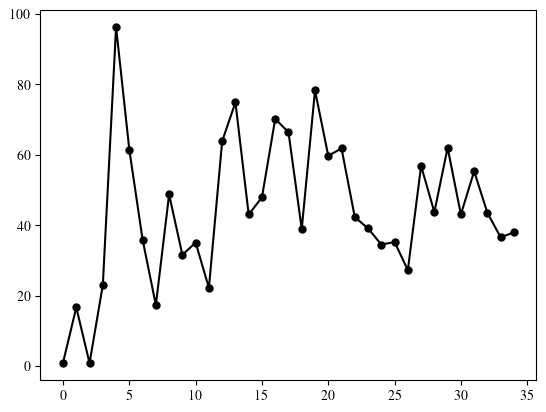

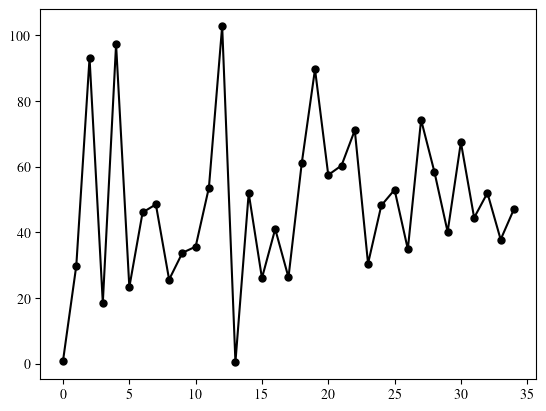

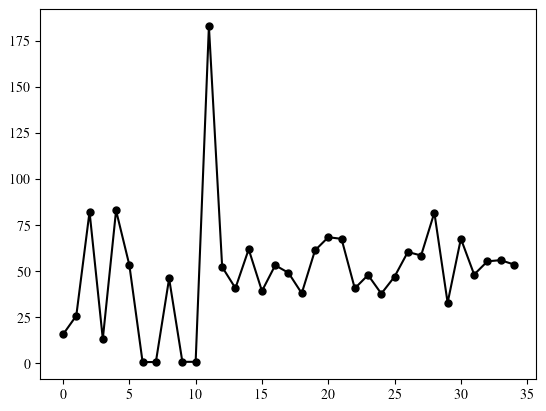

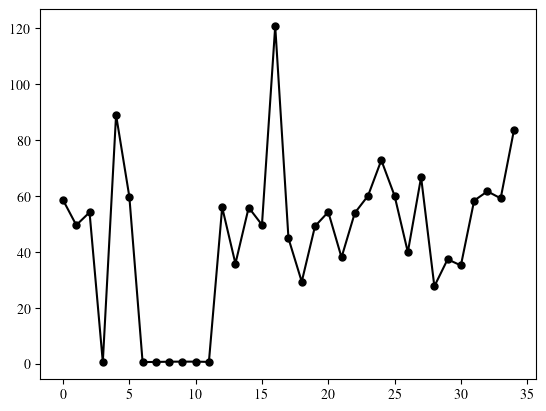

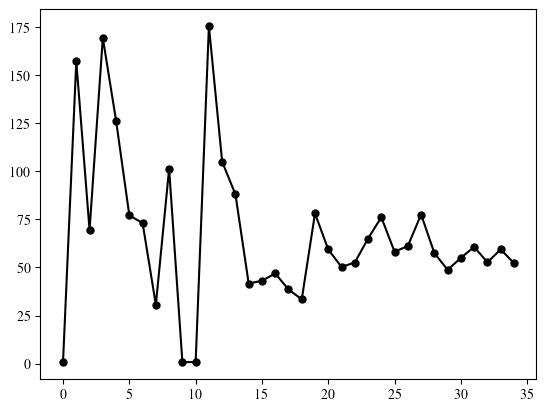

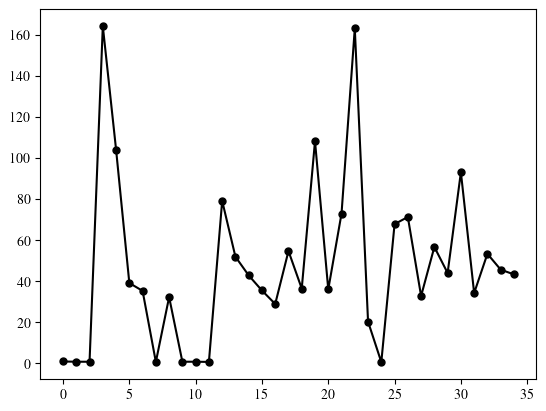

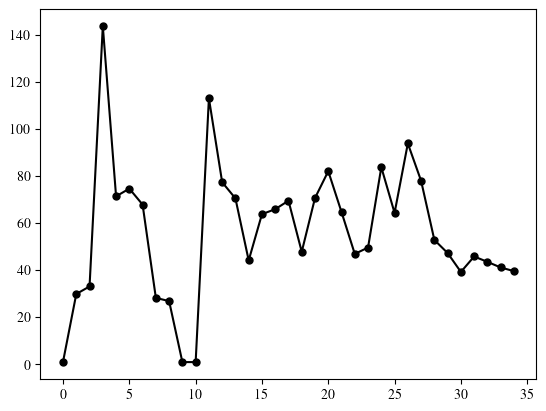

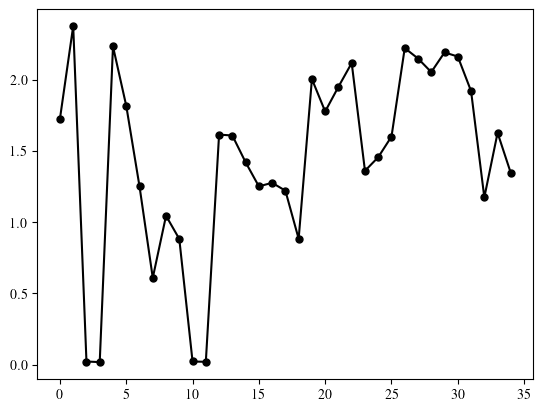

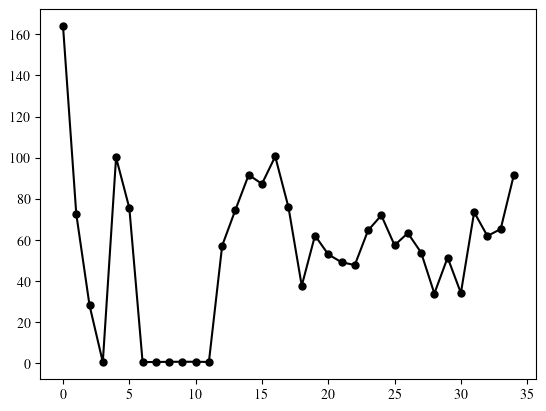

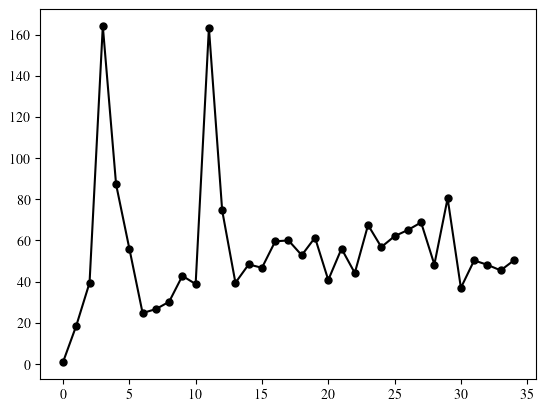

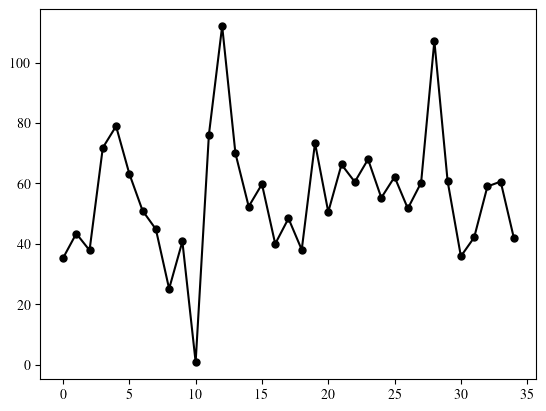

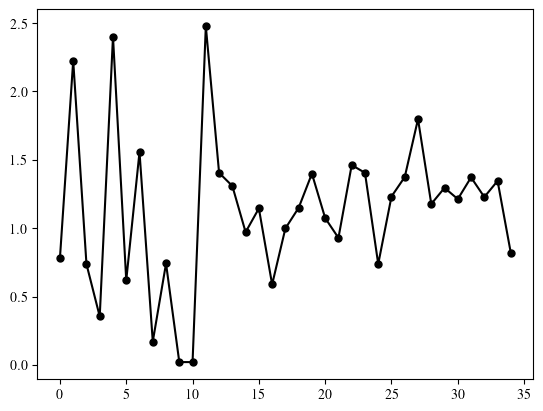

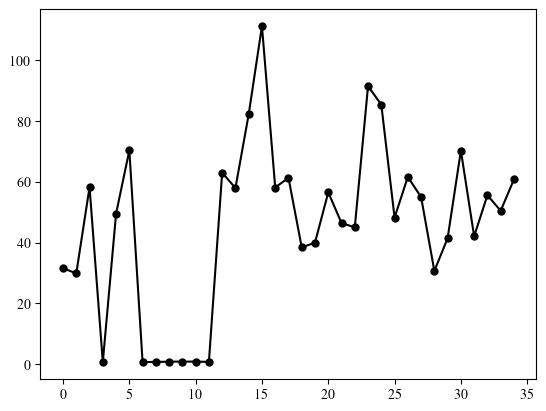

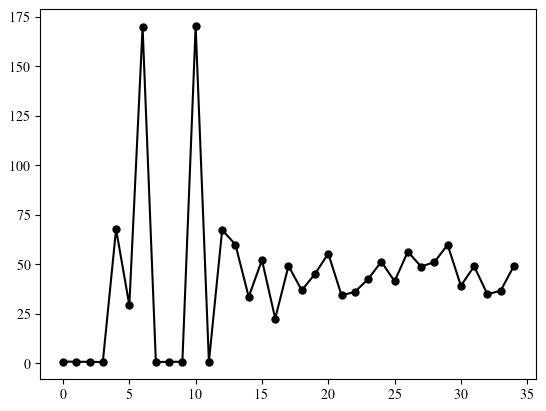

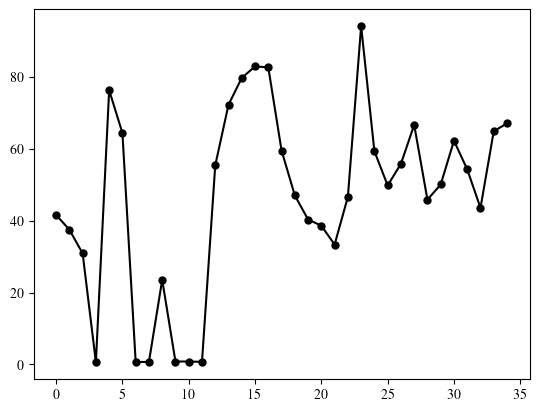

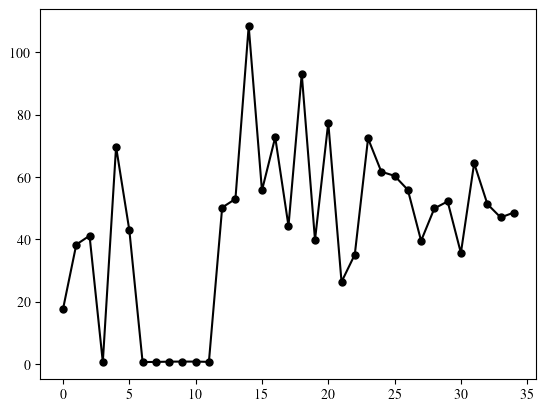

In [76]:
for j in range(X.shape[0]):
    plt.plot(X[j], marker='o', markersize=5, linewidth=1.5, color='black')
    plt.show(block=False)


In [3]:
import hierarchical_hawkes as hhf

For plotting, we use `matplotlib` with LaTeX rendering via `tikz` for high-quality figures. Lines 3 and 4 in the following code block configure LaTeX rendering with Times font. These lines can be removed if standard matplotlib rendering is preferred; in that case, only `import matplotlib.pyplot as plt` is required.

In [4]:
import matplotlib.pyplot as plt
## Compile with tikz and times font
plt.rc('text', usetex=True)
plt.rc('font', family='times')

Next, we perform K-means clustering with $K=3$ to partition the time series data into groups. For each group, we compute the average time series and fit hierarchical Hawkes functions separately to capture the distinct dynamics within each cluster.

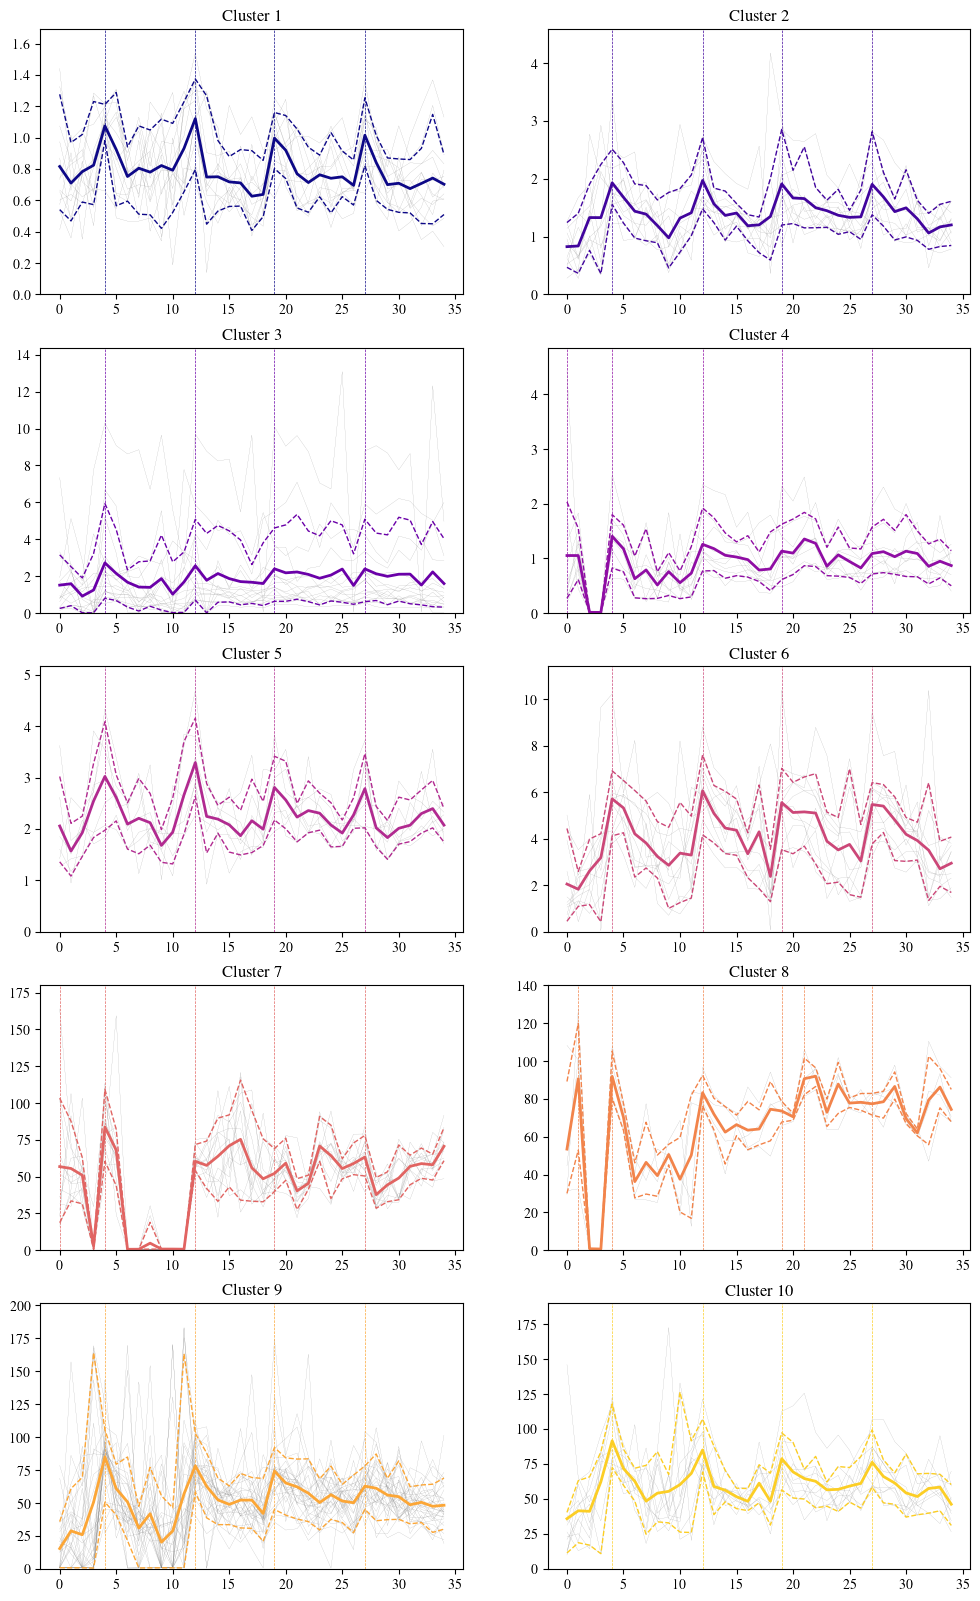

In [50]:
K = int(np.max(z) + 1)  # Number of clusters
jumps = np.array([ 3, 11, 18, 26]) + 1
## Colour palette
colors = plt.get_cmap('plasma').colors
## Plot the clusters in three separate plots
fig, ax = plt.subplots(5, 2, figsize=(12, 20))
for k in range(K):
    ## Select the time series in cluster k
    Xl = X[z == k]
    ## Mean of the time series in cluster k
    Xlm = Xl.mean(axis=0)
    ax[k // 2, k % 2].plot(Xl.T, markersize=2, linewidth=0.1, c='gray')
    ## Percentile lines
    percentXl = np.percentile(Xl, [10, 90], axis=0)
    ## Plot the percentiles
    ax[k // 2, k % 2].plot(percentXl[0], markersize=2, linewidth=1, color=colors[int(k / K * len(colors))], linestyle='--')
    ax[k // 2, k % 2].plot(percentXl[1], markersize=2, linewidth=1, color=colors[int(k / K * len(colors))], linestyle='--')
    for jump in jumps:
        ax[k // 2, k % 2].axvline(x=jump, color=colors[int(k / K * len(colors))], linestyle='--', linewidth=0.5)
    if k in [3, 6]:
        ax[k // 2, k % 2].axvline(x=0, color=colors[int(k / K * len(colors))], linestyle='--', linewidth=0.5)
    if k == 7: 
        ax[k // 2, k % 2].axvline(x=1, color=colors[int(k / K * len(colors))], linestyle='--', linewidth=0.5)
        ax[k // 2, k % 2].axvline(x=21, color=colors[int(k / K * len(colors))], linestyle='--', linewidth=0.5)
    ax[k // 2, k % 2].plot(Xlm, markersize=2, linewidth=2, color=colors[int(k / K * len(colors))])
    ax[k // 2, k % 2].set_title('Cluster ' + str(k+1))
    ax[k // 2, k % 2].set_ylim(0, np.max(Xl)+ np.max(Xl) / 10)
plt.savefig('../figures/time_series_clusters_10.pdf', bbox_inches='tight')
plt.show()


The HHFs are then fitted separately for the average time series for each cluster: 

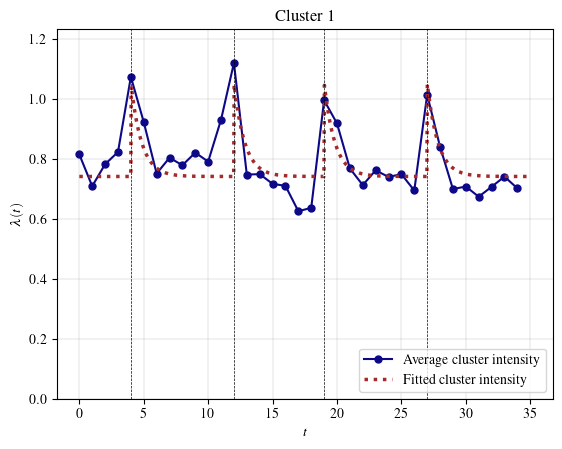

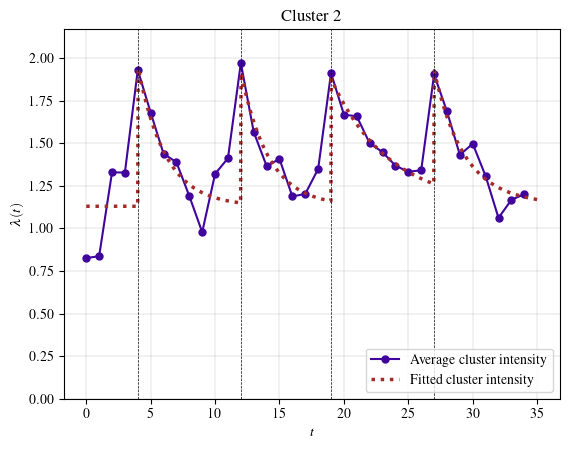

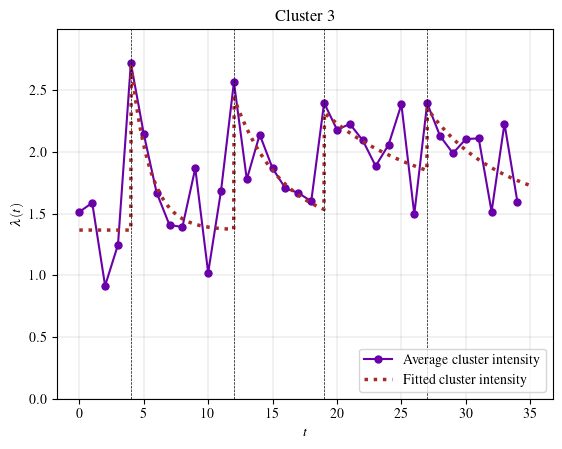

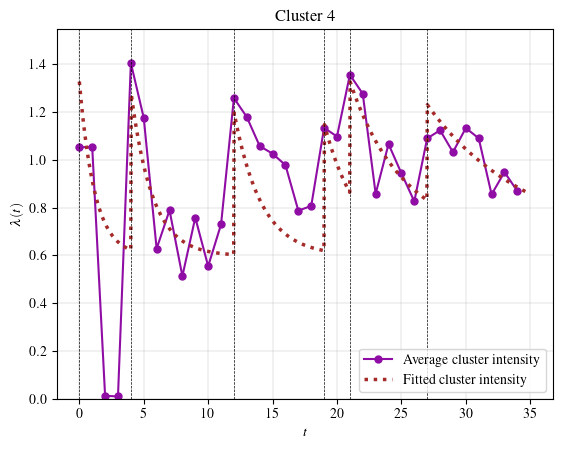

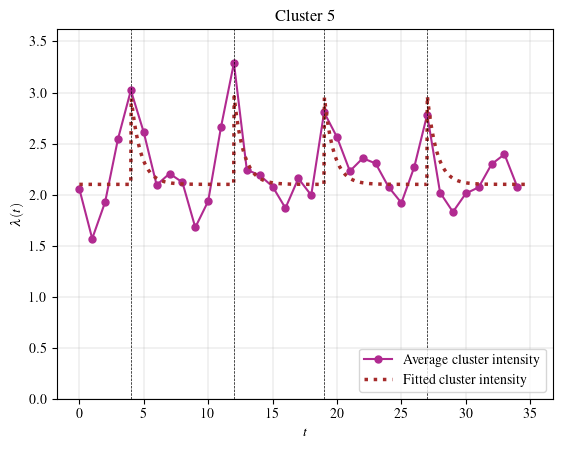

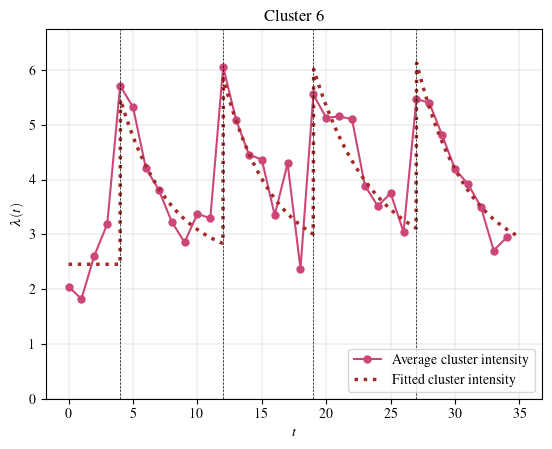

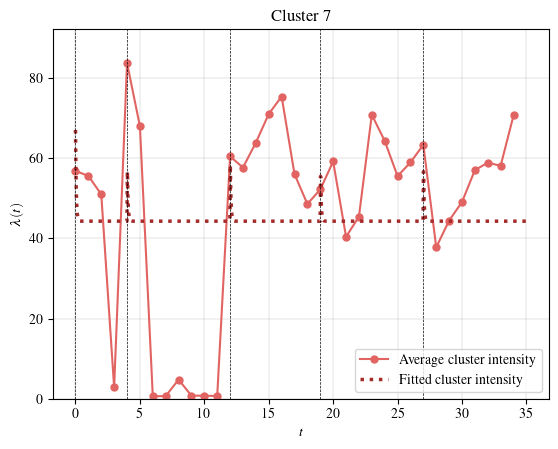

/Users/fs4515/Documents/github/hierarchical_hawkes/lib/hierarchical_hawkes/hhf.py:51: RuntimeWarning: overflow encountered in exp
  ints += alphas[j] * np.exp(-betas[j] * (time_grid - jump)) * np.heaviside(time_grid - jump, 1) ## Returns 1 if time_grid >= jump, else 0
/Users/fs4515/Documents/github/hierarchical_hawkes/lib/hierarchical_hawkes/hhf.py:51: RuntimeWarning: invalid value encountered in multiply
  ints += alphas[j] * np.exp(-betas[j] * (time_grid - jump)) * np.heaviside(time_grid - jump, 1) ## Returns 1 if time_grid >= jump, else 0
/Users/fs4515/Documents/github/hierarchical_hawkes/lib/hierarchical_hawkes/hhf.py:42: RuntimeWarning: overflow encountered in exp
  lambda0, theta0_alpha, eta_alpha, csi_alpha, theta0_beta, eta_beta, csi_beta = np.exp(params)
/Users/fs4515/Documents/github/hierarchical_hawkes/lib/hierarchical_hawkes/hhf.py:51: RuntimeWarning: overflow encountered in multiply
  ints += alphas[j] * np.exp(-betas[j] * (time_grid - jump)) * np.heaviside(time_grid - jum

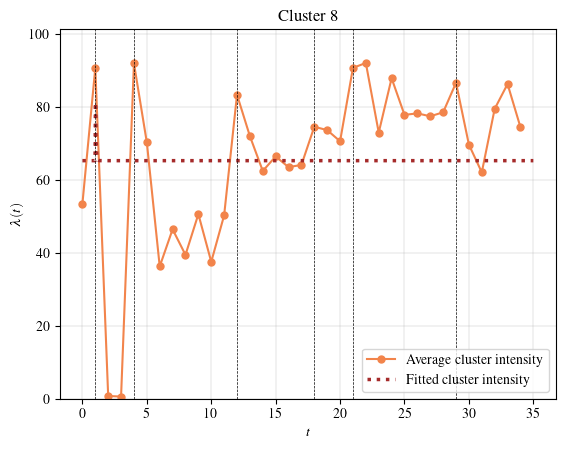

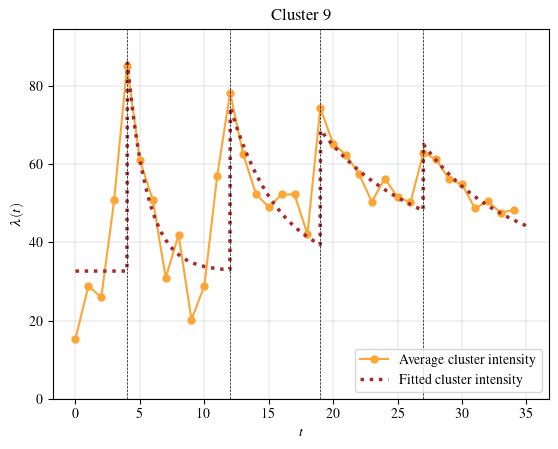

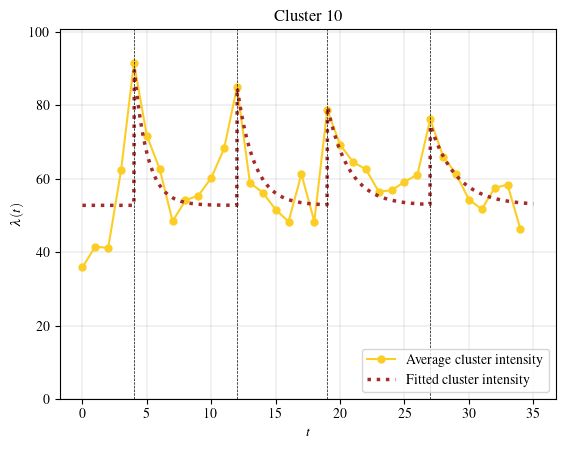

In [53]:
from scipy.optimize import minimize
## Repeat for all clusters
optimized_params_full = {}
for k in range(K):
    ## Pre-specify the jump locations
    jumps = np.array([3, 11, 18, 26]) + 1  # Adjust for zero-based indexing
    if k == 3 or k == 6:
        jumps = np.copy(jumps)
        ## Append a jump at the beginning
        jumps = np.insert(jumps, 0, 0)
    if k == 3: 
        ## Add a changepoint at 21
        jumps = np.insert(jumps, 2, 21)
    if k == 7: 
        ## Change the changepoint at 19 to 18
        jumps[2] = 18
        ## Change the changepoint at 27 to 29
        jumps[3] = 29
        ## Add a changepoint at 1
        jumps = np.insert(jumps, 0, 1)
        ## Add a changepoint at 21
        jumps = np.insert(jumps, 2, 21)
        ## Sort jumps
        jumps = np.sort(jumps)
    # Initial parameter guess (see paper for details)
    Xlm = X[z == k].mean(axis=0)
    if k == 3 or k == 6:
        lambda0 = np.mean(Xlm)
    else:
        lambda0 = np.mean(Xlm[jumps[0]:jumps[1]])
    if k == 3 or k == 6:
        alphas0 = np.append(Xlm[0], np.diff(Xlm)[jumps[1:] - 1])
    else:
        alphas0 = np.diff(Xlm)[jumps - 1]
    theta0_alpha0 = alphas0[0]
    eta_alpha0 = np.abs(alphas0[1] - alphas0[0])
    csi_alpha0 = 0.1  # Initial guess for csi
    params = np.log([theta0_alpha0, eta_alpha0, csi_alpha0])
    res_alpha = minimize(hhf.inhibitory_loss, params, args=(alphas0, jumps), method='L-BFGS-B')
    params = np.log([lambda0] + list(np.exp(res_alpha.x)) + [0.35, 0.2, 0.1])
    # Minimize the negative log-likelihood
    result = minimize(hhf.negative_log_likelihood, params, args=(Xlm, jumps), method='L-BFGS-B')
    # Extract the optimized parameters
    optimized_params = np.exp(result.x)
    optimized_params_full[k] = optimized_params
    ## Obtain the optimized parameters
    lambda0, theta0_alpha, eta_alpha, csi_alpha, theta0_beta, eta_beta, csi_beta = optimized_params
    ## Obtain the values of alpha and beta at the jump locations
    alphas = hhf.inhibitory_hawkes_intensity(jumps, jumps, theta0_alpha, eta_alpha, csi_alpha)
    betas = hhf.inhibitory_hawkes_intensity(jumps, jumps, theta0_beta, eta_beta, csi_beta)
    ## Grid
    time_grid = np.linspace(0, X.shape[1], 1000)
    ints = np.ones_like(time_grid) * lambda0
    # Calculate the intensity function
    for j, jump in enumerate(jumps):
        ints += alphas[j] * np.exp(-betas[j] * (time_grid - jump)) * np.heaviside(time_grid - jump, 1)
    ## Plot the optimized intensity function
    plt.plot(Xlm, color=colors[int(k / K * len(colors))], linewidth=1.5, marker='o', markersize=5,
             label='Average cluster intensity')
    plt.plot(time_grid, ints, color='brown', linewidth=2.5, ls='dotted', label='Fitted cluster intensity')
    plt.ylim(0, max([np.max(ints) + np.max(ints) / 10, np.max(Xlm) + np.max(Xlm) / 10]))
    plt.xlabel(r'$t$')
    plt.ylabel(r'$\lambda(t)$')
    for jump in jumps:
        plt.axvline(x=jump, color='black', linestyle='--', linewidth=0.5)
    plt.legend(loc='lower right')
    plt.grid(linewidth=0.25)
    plt.title(f'Cluster {k+1}')
    plt.savefig(f'../figures/hhf_nicks_groups_{k}.pdf', bbox_inches='tight')
    plt.show()